# 📊 Brazilian E-Commerce Business Intelligence Analysis
### Studi Kasus: Olist Store Public Dataset (2016–2018)

**Role simulation:** Data Analyst / Business Intelligence Analyst

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — 100k+ order dari marketplace Olist di Brazil, mencakup data order, customer, produk, seller, pembayaran, dan review.

---

## 1. Business Understanding

**Latar belakang:**
Olist adalah marketplace yang menghubungkan seller kecil-menengah di Brazil dengan berbagai online marketplace besar. Manajemen ingin memahami performa bisnis secara menyeluruh untuk mendukung pengambilan keputusan terkait revenue growth, kepuasan pelanggan, dan efisiensi logistik.

**Business Questions yang akan dijawab pada notebook ini:**

| # | Business Question | Kategori |
|---|---|---|
| 1 | Bagaimana tren revenue dan volume order dari waktu ke waktu? Apakah ada pola musiman? | Sales Performance |
| 2 | Kategori produk apa yang paling berkontribusi terhadap revenue dan mana yang under-performing? | Product Analysis |
| 3 | Bagaimana distribusi pelanggan & revenue berdasarkan wilayah (state)? | Geographic Analysis |
| 4 | Seberapa baik performa pengiriman (on-time delivery rate)? Wilayah mana yang paling sering telat? | Delivery/Logistics |
| 5 | Apakah keterlambatan pengiriman berkorelasi dengan review score pelanggan? | Customer Satisfaction |
| 6 | Bagaimana perilaku pembayaran pelanggan (metode & cicilan)? | Payment Behavior |
| 7 | Siapa pelanggan paling bernilai (RFM segmentation)? Bagaimana strategi retensinya? | Customer Segmentation |
| 8 | Bagaimana tingkat retensi pelanggan dari bulan ke bulan (cohort analysis)? | Customer Retention |
| 9 | Seller mana yang berkinerja terbaik/terburuk, dan apa dampaknya ke bisnis? | Seller Performance |
| 10 | Apakah keterlambatan pengiriman secara statistik signifikan menurunkan review score? | Statistical Validation |

**Tools & Metodologi:** Python (Pandas, NumPy) untuk data wrangling; Matplotlib/Seaborn untuk visualisasi; SciPy untuk uji statistik; Scikit-learn untuk segmentasi (RFM + K-Means). Output akhir berupa tabel-tabel siap pakai untuk dashboard (Power BI/Tableau/Looker Studio).

**Struktur Notebook:**
1. Data Understanding & Quality Assessment
2. Data Cleaning & Integration (ETL)
3. Feature Engineering & Validation
4. Exploratory Data Analysis (EDA) & Visualisasi
5. Customer Segmentation (RFM + Clustering)
6. Cohort / Retention Analysis
7. Seller Performance Analysis
8. Statistical Hypothesis Testing
9. Business Insights & Rekomendasi
10. Export Dashboard-Ready Dataset


## 2. Import Library

In [1]:
# 2. Import Library

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Visualization style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

print("Libraries imported successfully")


Libraries imported successfully


## 3. Konfigurasi Path Dataset


In [2]:
# 3. Konfigurasi Path Dataset

# Ubah DATA_PATH sesuai lokasi dataset di komputer Anda,
# atau set environment variable OLIST_DATA_PATH sebelum menjalankan notebook.
DATA_PATH = Path(os.environ.get("OLIST_DATA_PATH", "./data_e-commerse/"))
OUTPUT_PATH = Path("./data/processed")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

REQUIRED_FILES = [
    "olist_customers_dataset.csv",
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_products_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_sellers_dataset.csv",
    "product_category_name_translation.csv",
]

missing = [f for f in REQUIRED_FILES if not (DATA_PATH / f).exists()]
if missing:
    print("⚠️  File berikut tidak ditemukan di", DATA_PATH.resolve())
    for f in missing:
        print("   -", f)
    print("\nSilakan download dataset dari Kaggle (Brazilian E-Commerce Public Dataset by Olist)")
    print("lalu letakkan di folder di atas, atau set environment variable OLIST_DATA_PATH.")
else:
    print(f"✅ Semua file dataset ditemukan di: {DATA_PATH.resolve()}")


✅ Semua file dataset ditemukan di: C:\Users\HP\Downloads\data_e-commerse


## 4. Load Raw Dataset

In [3]:
# 4. Load Raw Dataset

customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_PATH / "olist_products_dataset.csv")
payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")
sellers = pd.read_csv(DATA_PATH / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(DATA_PATH / "product_category_name_translation.csv")

datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "payments": payments,
    "reviews": reviews,
    "sellers": sellers,
    "category_translation": category_translation,
}

print("Raw datasets loaded successfully")
print(f"Total tables: {len(datasets)}")


Raw datasets loaded successfully
Total tables: 8


## 5. Data Understanding


In [4]:
# 5.1 Fungsi ringkasan reusable

def summarize_df(name, df):
    return {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": int(df.isnull().sum().sum()),
        "missing_pct": round(df.isnull().sum().sum() / df.size * 100, 2),
        "duplicate_rows": int(df.duplicated().sum()),
        "memory_mb": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
    }

summary_table = pd.DataFrame([summarize_df(name, df) for name, df in datasets.items()])
summary_table.sort_values("rows", ascending=False, inplace=True)
summary_table


,dataset,rows,columns,missing_values,missing_pct,duplicate_rows,memory_mb
2,order_items,112650,7,0,0.00,0,39.43
4,payments,103886,5,0,0.00,0,17.81
0,customers,99441,5,0,0.00,0,29.62
1,orders,99441,8,4908,0.62,0,58.97
5,reviews,99224,7,145903,21.01,0,42.75
3,products,32951,9,2448,0.83,0,6.79
6,sellers,3095,4,0,0.00,0,0.66
7,category_translation,71,2,0,0.00,0,0.01


In [5]:
# 5.2 Preview struktur tiap dataset (kolom & tipe data)

for name, df in datasets.items():
    print(f"\n{'='*70}\nDATASET: {name.upper()}  |  shape={df.shape}\n{'='*70}")
    display(df.head(3))
    print("\nDtypes:")
    print(df.dtypes)



DATASET: CUSTOMERS  |  shape=(99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



Dtypes:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

DATASET: ORDERS  |  shape=(99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



Dtypes:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

DATASET: ORDER_ITEMS  |  shape=(112650, 7)


...


Dtypes:
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object

DATASET: SELLERS  |  shape=(3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



Dtypes:
seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object

DATASET: CATEGORY_TRANSLATION  |  shape=(71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto



Dtypes:
product_category_name            object
product_category_name_english    object
dtype: object


In [6]:
# 5.3 Detail missing values per kolom (hanya kolom yang punya missing)

for name, df in datasets.items():
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss) > 0:
        print(f"\n{name}:")
        print((miss / len(df) * 100).round(2).astype(str) + "%")



orders:
order_approved_at                0.16%
order_delivered_carrier_date     1.79%
order_delivered_customer_date    2.98%
dtype: object

products:
product_category_name         1.85%
product_name_lenght           1.85%
product_description_lenght    1.85%
product_photos_qty            1.85%
product_weight_g              0.01%
product_length_cm             0.01%
product_height_cm             0.01%
product_width_cm              0.01%
dtype: object

reviews:
review_comment_title      88.34%
review_comment_message     58.7%
dtype: object


**Catatan temuan Data Understanding:**
- Kolom tanggal delivery di `orders` punya missing value bertingkat sesuai tahapan proses: `order_approved_at` 0.16%, `order_delivered_carrier_date` 1.79%, `order_delivered_customer_date` 2.98%. Ini **valid secara bisnis** — order yang belum sampai tahap tersebut (masih diproses/dibatalkan) memang belum punya tanggalnya, bukan data error.
- Kolom review (`review_comment_title` 88.34% missing, `review_comment_message` 58.7% missing) — wajar, karena mayoritas pelanggan hanya memberi skor tanpa menulis komentar.
- `product_category_name` di `products` missing 1.85% — sudah ditangani dengan label `"unknown"` pada tahap cleaning agar tidak hilang saat agregasi (kategori ini bahkan tercatat menyumbang revenue ±R$185 ribu di analisis kategori, sehingga tidak boleh dibuang).
- Tidak ditemukan baris duplikat sama sekali di kedelapan tabel.


## 6. Data Quality Assessment

Sebelum membersihkan data, kita cek dulu potensi masalah kualitas data: outlier, kardinalitas kolom kategorikal, dan konsistensi nilai (misalnya `order_status` apa saja yang ada).


In [7]:
# 6.1 Order status yang ada — penting untuk menentukan filter revenue yang valid
print("Distribusi order_status:")
display(orders["order_status"].value_counts())
print("\nPersentase:")
display((orders["order_status"].value_counts(normalize=True) * 100).round(2))


Distribusi order_status:


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


Persentase:


order_status
delivered     97.02
shipped        1.11
canceled       0.63
unavailable    0.61
invoiced       0.32
processing     0.30
created        0.01
approved       0.00
Name: proportion, dtype: float64

In [8]:
# 6.2 Deteksi outlier pada price & freight_value menggunakan metode IQR

def iqr_outlier_report(series, name):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outlier = ((series < lower) | (series > upper)).sum()
    print(f"{name}: Q1={q1:.2f}, Q3={q3:.2f}, IQR bound=({lower:.2f}, {upper:.2f}), "
          f"outliers={n_outlier} ({n_outlier/len(series)*100:.2f}%)")

iqr_outlier_report(order_items["price"], "price")
iqr_outlier_report(order_items["freight_value"], "freight_value")

# Catatan: outlier TIDAK langsung dibuang di kasus ini, karena barang mahal (misal furniture,
# elektronik) memang valid punya harga tinggi. Outlier akan divisualisasikan pada tahap EDA
# untuk menilai apakah representasi wajar bisnis atau anomali entri data.


price: Q1=39.90, Q3=134.90, IQR bound=(-102.60, 277.40), outliers=8427 (7.48%)
freight_value: Q1=13.08, Q3=21.15, IQR bound=(0.98, 33.25), outliers=12134 (10.77%)


## 7. Data Cleaning

**Strategi pembersihan data (didokumentasikan agar auditable):**
| Data | Perlakuan | Alasan |
|---|---|---|
| Kolom tanggal di `orders`/`reviews` | Konversi ke `datetime`, `errors="coerce"` | Format tanggal harus konsisten untuk perhitungan durasi |
| Missing tanggal delivery | Dibiarkan NaT, tidak di-drop | NaT valid untuk order yang belum terkirim/dibatalkan — informasi bisnis, bukan error |
| Duplicate rows | Dihapus dengan `drop_duplicates()` | Duplikat murni tidak menambah informasi dan bisa menggelembungkan angka |
| `product_category_name` kosong | Diisi `"unknown"` | Supaya tetap bisa diagregasi tanpa hilang baris data |
| `price`/`freight_value` non-numeric | Coerce ke `NaN` lalu dihitung persentasenya | Menjaga transparansi jumlah data yang rusak |


In [9]:
# 7.1 Customers
customers_clean = customers.drop_duplicates().copy()
customers_clean["customer_zip_code_prefix"] = customers_clean["customer_zip_code_prefix"].astype("string")
customers_clean["customer_city"] = customers_clean["customer_city"].str.title().astype("string")
customers_clean["customer_state"] = customers_clean["customer_state"].astype("string")

# 7.2 Orders
orders_clean = orders.drop_duplicates().copy()
date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors="coerce")

# 7.3 Order Items
order_items_clean = order_items.drop_duplicates().copy()
order_items_clean["price"] = pd.to_numeric(order_items_clean["price"], errors="coerce")
order_items_clean["freight_value"] = pd.to_numeric(order_items_clean["freight_value"], errors="coerce")
n_bad_price = order_items_clean["price"].isnull().sum()
print(f"order_items dengan price tidak valid (jadi NaN): {n_bad_price}")

# 7.4 Products
products_clean = products.drop_duplicates().copy()
products_clean = products_clean.merge(category_translation, on="product_category_name", how="left")
products_clean["product_category_name_english"] = (
    products_clean["product_category_name_english"].fillna("unknown")
)
for col in ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]:
    products_clean[col] = pd.to_numeric(products_clean[col], errors="coerce")

# 7.5 Payments
payments_clean = payments.drop_duplicates().copy()
payments_clean["payment_value"] = pd.to_numeric(payments_clean["payment_value"], errors="coerce")

# 7.6 Reviews
reviews_clean = reviews.drop_duplicates(subset=["review_id", "order_id"]).copy()
reviews_clean["review_score"] = pd.to_numeric(reviews_clean["review_score"], errors="coerce")
reviews_clean["review_creation_date"] = pd.to_datetime(reviews_clean["review_creation_date"], errors="coerce")
reviews_clean["review_answer_timestamp"] = pd.to_datetime(reviews_clean["review_answer_timestamp"], errors="coerce")

# 7.7 Sellers
sellers_clean = sellers.drop_duplicates().copy()
sellers_clean["seller_zip_code_prefix"] = sellers_clean["seller_zip_code_prefix"].astype("string")
sellers_clean["seller_city"] = sellers_clean["seller_city"].str.title().astype("string")
sellers_clean["seller_state"] = sellers_clean["seller_state"].astype("string")

print("Cleaning completed for all datasets")


order_items dengan price tidak valid (jadi NaN): 0
Cleaning completed for all datasets


## 8. Data Integration — Membentuk Fact Table


In [10]:
# 8. Data Integration

fact_ecommerce_sales = order_items_clean.merge(orders_clean, on="order_id", how="left")
fact_ecommerce_sales = fact_ecommerce_sales.merge(customers_clean, on="customer_id", how="left")
fact_ecommerce_sales = fact_ecommerce_sales.merge(products_clean, on="product_id", how="left")
fact_ecommerce_sales = fact_ecommerce_sales.merge(sellers_clean, on="seller_id", how="left")

# Payment per order (total dibayar + metode pembayaran utama)
payments_summary = (
    payments_clean
    .groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_type=("payment_type", lambda x: x.mode().iat[0] if not x.mode().empty else np.nan),
        payment_installments=("payment_installments", "max"),
    )
)
fact_ecommerce_sales = fact_ecommerce_sales.merge(payments_summary, on="order_id", how="left")

# Review per order (rata-rata jika ada lebih dari 1 review)
review_summary = (
    reviews_clean
    .groupby("order_id", as_index=False)
    .agg(review_score=("review_score", "mean"))
)
fact_ecommerce_sales = fact_ecommerce_sales.merge(review_summary, on="order_id", how="left")

print(f"Fact table shape: {fact_ecommerce_sales.shape}")
fact_ecommerce_sales.head()


Fact table shape: (112650, 34)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_type,payment_installments,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,Campos Dos Goytacazes,RJ,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,cool_stuff,27277,Volta Redonda,SP,72.19,credit_card,2.00,5.00
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,Santa Fe Do Sul,SP,pet_shop,56.00,239.00,2.00,"30,000.00",50.00,30.00,40.00,pet_shop,3471,Sao Paulo,SP,259.83,credit_card,3.00,4.00
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,Para De Minas,MG,moveis_decoracao,59.00,695.00,2.00,"3,050.00",33.00,13.00,33.00,furniture_decor,37564,Borda Da Mata,MG,216.87,credit_card,5.00,5.00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,Atibaia,SP,perfumaria,42.00,480.00,1.00,200.00,16.00,10.00,15.00,perfumery,14403,Franca,SP,25.78,credit_card,2.00,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,Varzea Paulista,SP,ferramentas_jardim,59.00,409.00,1.00,"3,750.00",35.00,40.00,30.00,garden_tools,87900,Loanda,PR,218.04,credit_card,3.00,5.00


## 9. Feature Engineering

Fitur turunan yang ditambahkan untuk mendukung seluruh business question di atas:

| Fitur | Deskripsi |
|---|---|
| `gross_merchandise_value` | Nilai barang (price) — pendapatan kotor seller |
| `freight_cost` | Biaya ongkos kirim (dipisah dari revenue) |
| `order_year`, `order_month`, `order_month_year`, `order_weekday` | Untuk analisis tren waktu |
| `delivery_days` | Lama pengiriman aktual (purchase → delivered) |
| `is_delivered` | Flag order sukses sampai ke pelanggan |
| `is_late` | Flag keterlambatan (delivered_date > estimated_date) |
| `delivery_delay_days` | Selisih hari keterlambatan (positif = telat) |
| `price_segment` | Segmentasi harga produk (Low/Mid/High/Premium) |
| `customer_type` | new vs repeat customer |
| `review_category` | Positive (4-5) / Neutral (3) / Negative (1-2) |


In [11]:
# 9.1 Revenue components (dipisah, bukan digabung)
fact_ecommerce_sales["gross_merchandise_value"] = fact_ecommerce_sales["price"]
fact_ecommerce_sales["freight_cost"] = fact_ecommerce_sales["freight_value"]

# 9.2 Time-based features
fact_ecommerce_sales["order_year"] = fact_ecommerce_sales["order_purchase_timestamp"].dt.year
fact_ecommerce_sales["order_month"] = fact_ecommerce_sales["order_purchase_timestamp"].dt.month
fact_ecommerce_sales["order_month_year"] = fact_ecommerce_sales["order_purchase_timestamp"].dt.to_period("M").astype(str)
fact_ecommerce_sales["order_weekday"] = fact_ecommerce_sales["order_purchase_timestamp"].dt.day_name()

# 9.3 Delivery performance
fact_ecommerce_sales["is_delivered"] = fact_ecommerce_sales["order_status"].eq("delivered")

fact_ecommerce_sales["delivery_days"] = (
    fact_ecommerce_sales["order_delivered_customer_date"] - fact_ecommerce_sales["order_purchase_timestamp"]
).dt.days
# delivery_days hanya valid utk order yang sudah delivered; selain itu NaN by design (bukan bug)

fact_ecommerce_sales["delivery_delay_days"] = (
    fact_ecommerce_sales["order_delivered_customer_date"] - fact_ecommerce_sales["order_estimated_delivery_date"]
).dt.days
fact_ecommerce_sales["is_late"] = fact_ecommerce_sales["delivery_delay_days"] > 0

# 9.4 Price segmentation
fact_ecommerce_sales["price_segment"] = pd.cut(
    fact_ecommerce_sales["price"],
    bins=[0, 50, 150, 400, np.inf],
    labels=["Low (<=50)", "Mid (50-150)", "High (150-400)", "Premium (>400)"],
)

# 9.5 Customer type: new vs repeat (berdasarkan jumlah order unik per customer_unique_id)
order_count_per_customer = fact_ecommerce_sales.groupby("customer_unique_id")["order_id"].nunique()
repeat_customers = order_count_per_customer[order_count_per_customer > 1].index
fact_ecommerce_sales["customer_type"] = np.where(
    fact_ecommerce_sales["customer_unique_id"].isin(repeat_customers), "repeat", "new"
)

# 9.6 Review category
def review_bucket(score):
    if pd.isna(score):
        return np.nan
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

fact_ecommerce_sales["review_category"] = fact_ecommerce_sales["review_score"].apply(review_bucket)

# 9.7 Seller-level metrics (agregat, di-merge balik ke fact table)
seller_metrics = (
    fact_ecommerce_sales
    .groupby("seller_id", as_index=False)
    .agg(
        seller_total_revenue=("gross_merchandise_value", "sum"),
        seller_total_orders=("order_id", "nunique"),
        seller_avg_delivery_days=("delivery_days", "mean"),
        seller_avg_review_score=("review_score", "mean"),
    )
)
fact_ecommerce_sales = fact_ecommerce_sales.merge(seller_metrics, on="seller_id", how="left")

print("Feature engineering selesai. Kolom baru:")
new_cols = ["gross_merchandise_value", "freight_cost", "order_month_year", "delivery_days",
            "is_delivered", "is_late", "delivery_delay_days", "price_segment",
            "customer_type", "review_category"]
fact_ecommerce_sales[new_cols].head()


Feature engineering selesai. Kolom baru:


,gross_merchandise_value,freight_cost,order_month_year,delivery_days,is_delivered,is_late,delivery_delay_days,price_segment,customer_type,review_category
0,58.90,13.29,2017-09,7.00,True,False,-9.00,Mid (50-150),new,Positive
1,239.90,19.93,2017-04,16.00,True,False,-3.00,High (150-400),repeat,Positive
2,199.00,17.87,2018-01,7.00,True,False,-14.00,High (150-400),new,Positive
3,12.99,12.79,2018-08,6.00,True,False,-6.00,Low (<=50),new,Positive
4,199.90,18.14,2017-02,25.00,True,False,-16.00,High (150-400),new,Positive


## 10. Data Validation (Sanity Check)

Sebelum data dipakai untuk analisis/dashboard, kita jalankan beberapa assertion sederhana untuk memastikan tidak ada anomali logika pada fact table.


In [12]:
# 10. Sanity checks

checks = []

checks.append(("Tidak ada revenue negatif",
               (fact_ecommerce_sales["gross_merchandise_value"].dropna() >= 0).all()))

checks.append(("Tidak ada freight_cost negatif",
               (fact_ecommerce_sales["freight_cost"].dropna() >= 0).all()))

checks.append(("delivery_days hanya negatif jika data anomali (harus nyaris 0 kasus)",
               (fact_ecommerce_sales["delivery_days"].dropna() >= 0).mean() > 0.99))

checks.append(("Semua order_id di fact table ada di tabel orders asli",
               fact_ecommerce_sales["order_id"].isin(orders_clean["order_id"]).all()))

checks.append(("Tidak ada duplikat kombinasi order_id + order_item_id",
               fact_ecommerce_sales.duplicated(subset=["order_id", "order_item_id"]).sum() == 0))

for desc, result in checks:
    status = "✅ PASS" if result else "❌ FAIL"
    print(f"{status} — {desc}")


✅ PASS — Tidak ada revenue negatif
✅ PASS — Tidak ada freight_cost negatif
✅ PASS — delivery_days hanya negatif jika data anomali (harus nyaris 0 kasus)
✅ PASS — Semua order_id di fact table ada di tabel orders asli
✅ PASS — Tidak ada duplikat kombinasi order_id + order_item_id


## 11. Export Fact Table (cleaned & enriched)

In [13]:
# 11. Export fact table utama

output_file = OUTPUT_PATH / "fact_ecommerce_sales.csv"
fact_ecommerce_sales.to_csv(output_file, index=False)
print(f"Dataset exported to: {output_file.resolve()}")
print(f"Shape: {fact_ecommerce_sales.shape}")


Dataset exported to: C:\Users\HP\Downloads\data\processed\fact_ecommerce_sales.csv
Shape: (112650, 51)


## 12. Exploratory Data Analysis (EDA) & Visualisasi

### 12.1 Executive KPI Summary


In [14]:
# 12.1 Executive KPI Summary

delivered = fact_ecommerce_sales[fact_ecommerce_sales["is_delivered"]]

kpi = {
    "Total Revenue (GMV)": f"R$ {fact_ecommerce_sales['gross_merchandise_value'].sum():,.2f}",
    "Total Orders": f"{fact_ecommerce_sales['order_id'].nunique():,}",
    "Total Unique Customers": f"{fact_ecommerce_sales['customer_unique_id'].nunique():,}",
    "Average Order Value (AOV)": f"R$ {fact_ecommerce_sales.groupby('order_id')['gross_merchandise_value'].sum().mean():,.2f}",
    "Average Review Score": f"{fact_ecommerce_sales['review_score'].mean():.2f} / 5.0",
    "On-Time Delivery Rate": f"{(~delivered['is_late']).mean()*100:.1f}%",
    "Average Delivery Days": f"{delivered['delivery_days'].mean():.1f} hari",
    "Repeat Customer Rate": f"{(fact_ecommerce_sales.drop_duplicates('customer_unique_id')['customer_type']=='repeat').mean()*100:.1f}%",
}

print("="*55)
print("EXECUTIVE KPI SUMMARY".center(55))
print("="*55)
for k, v in kpi.items():
    print(f"{k:<32}: {v}")
print("="*55)


                 EXECUTIVE KPI SUMMARY                 
Total Revenue (GMV)             : R$ 13,591,643.70
Total Orders                    : 98,666
Total Unique Customers          : 95,420
Average Order Value (AOV)       : R$ 137.75
Average Review Score            : 4.03 / 5.0
On-Time Delivery Rate           : 93.4%
Average Delivery Days           : 12.0 hari
Repeat Customer Rate            : 3.1%


### 12.2 Tren Revenue & Volume Order dari Waktu ke Waktu
*(Menjawab Business Question #1)*


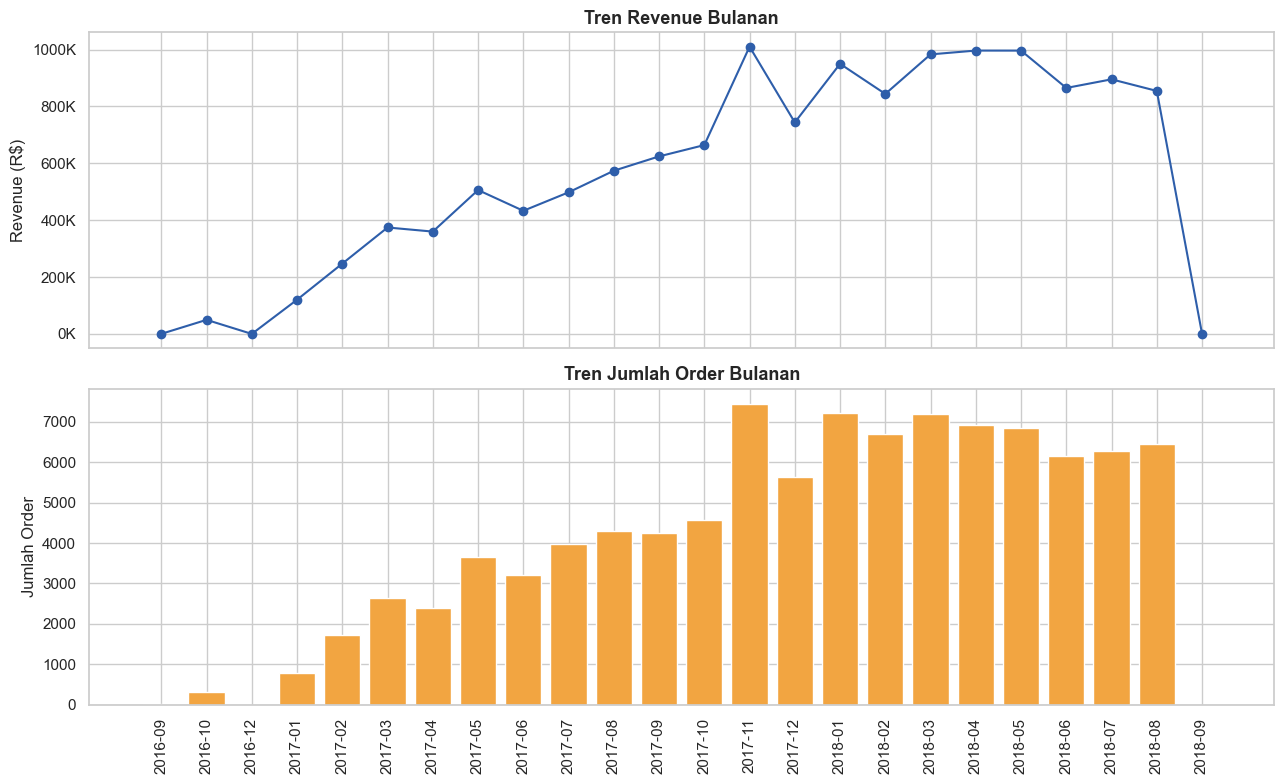


Bulan dengan revenue tertinggi:


,order_month_year,revenue,orders,revenue_growth_pct
13,2017-11,"1,010,271.37",7451,52.10
18,2018-04,"996,647.75",6934,1.37
19,2018-05,"996,517.68",6853,-0.01
17,2018-03,"983,213.44",7188,16.47
15,2018-01,"950,030.36",7220,27.71


In [15]:
# 12.2 Monthly revenue & order trend

monthly = (
    fact_ecommerce_sales
    .groupby("order_month_year", as_index=False)
    .agg(
        revenue=("gross_merchandise_value", "sum"),
        orders=("order_id", "nunique"),
    )
    .sort_values("order_month_year")
)
monthly["revenue_growth_pct"] = monthly["revenue"].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(monthly["order_month_year"], monthly["revenue"], marker="o", color="#2E5EAA")
axes[0].set_title("Tren Revenue Bulanan")
axes[0].set_ylabel("Revenue (R$)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
axes[0].tick_params(axis="x", rotation=90)

axes[1].bar(monthly["order_month_year"], monthly["orders"], color="#F2A541")
axes[1].set_title("Tren Jumlah Order Bulanan")
axes[1].set_ylabel("Jumlah Order")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

print("\nBulan dengan revenue tertinggi:")
display(monthly.sort_values("revenue", ascending=False).head(5))


**📌 Insight (berdasarkan hasil run):**
- Revenue tumbuh signifikan sepanjang 2017, dengan puncak tertinggi di **November 2017 (R$ 1.010.271, +52,1% MoM)** — lonjakan ini konsisten dengan periode Black Friday.
- Memasuki 2018, revenue relatif **mendatar (plateau)** di kisaran R$ 950rb–1jt per bulan (Jan, Mar, Apr, Mei 2018 semuanya di rentang ini), menandakan pertumbuhan mulai melambat dibanding lonjakan 2017.
- Bulan-bulan di awal dataset (sekitar Sep 2016) menunjukkan volume sangat kecil — ini adalah **data parsial** (marketplace baru mulai beroperasi/onboarding), bukan penurunan bisnis, sehingga tidak boleh dijadikan baseline perbandingan tren.
- **Rekomendasi:** replikasi strategi kampanye November (diskon besar/flash sale) ke bulan-bulan lain yang cenderung flat untuk mendorong pertumbuhan lanjutan di 2018.


### 12.3 Performa Kategori Produk
*(Menjawab Business Question #2)*


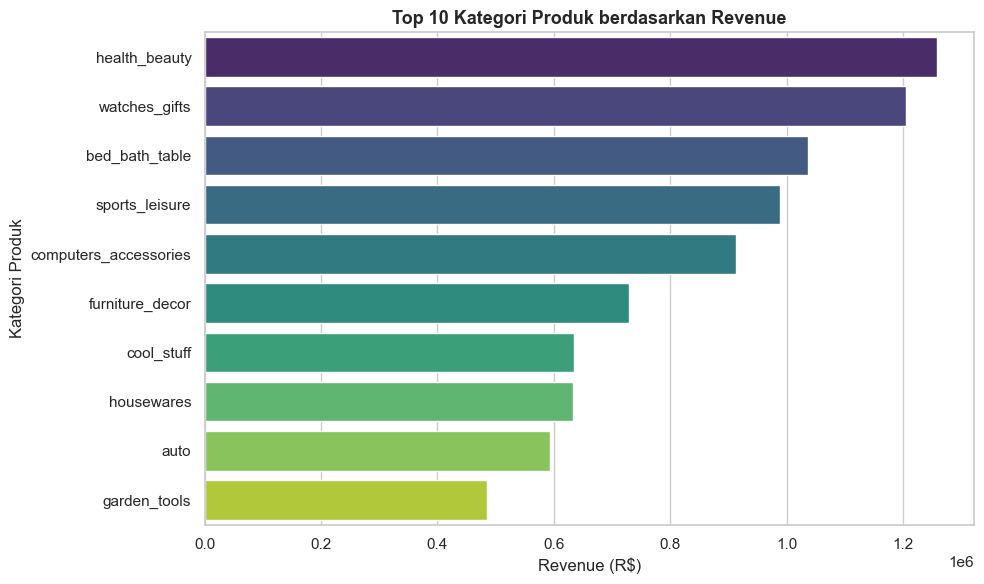

Bottom 10 kategori (revenue terendah, min. 5 order):


,product_category_name_english,revenue,orders,avg_review_score,avg_price
41,furniture_mattress_and_upholstery,"4,368.08",38,3.82,114.95
27,fashio_female_clothing,"2,803.64",39,3.78,58.41
32,fashion_sport,"2,119.51",27,4.23,70.65
52,la_cuisine,"2,054.99",13,4.00,146.78
3,arts_and_craftmanship,"1,814.01",23,4.12,75.58
23,diapers_and_hygiene,"1,567.59",27,3.26,40.19
35,flowers,"1,110.04",29,4.42,33.64
46,home_comfort_2,760.27,24,3.63,25.34
11,cds_dvds_musicals,730.00,12,4.64,52.14
29,fashion_childrens_clothes,569.85,8,4.50,71.23


In [16]:
# 12.3 Top & bottom category by revenue

category_perf = (
    fact_ecommerce_sales
    .groupby("product_category_name_english", as_index=False)
    .agg(
        revenue=("gross_merchandise_value", "sum"),
        orders=("order_id", "nunique"),
        avg_review_score=("review_score", "mean"),
        avg_price=("price", "mean"),
    )
    .sort_values("revenue", ascending=False)
)

top10 = category_perf.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top10, y="product_category_name_english", x="revenue", palette="viridis", ax=ax)
ax.set_title("Top 10 Kategori Produk berdasarkan Revenue")
ax.set_xlabel("Revenue (R$)")
ax.set_ylabel("Kategori Produk")
plt.tight_layout()
plt.show()

print("Bottom 10 kategori (revenue terendah, min. 5 order):")
display(category_perf[category_perf["orders"] >= 5].tail(10))


In [17]:
# 12.3b Kategori dengan review score terendah (kandidat masalah kualitas/ekspektasi produk)

worst_review_categories = (
    category_perf[category_perf["orders"] >= 20]
    .sort_values("avg_review_score")
    .head(10)
)
display(worst_review_categories)


,product_category_name_english,revenue,orders,avg_review_score,avg_price
23,diapers_and_hygiene,"1,567.59",27,3.26,40.19
57,office_furniture,"273,960.70",1273,3.49,162.01
46,home_comfort_2,760.27,24,3.63,25.34
30,fashion_male_clothing,"10,797.82",112,3.64,81.80
34,fixed_telephony,"59,583.00",217,3.68,225.69
58,party_supplies,"4,485.18",39,3.77,104.31
27,fashio_female_clothing,"2,803.64",39,3.78,58.41
41,furniture_mattress_and_upholstery,"4,368.08",38,3.82,114.95
70,unknown,"185,049.76",1473,3.83,113.74
4,audio,"50,688.50",350,3.83,139.25


### 12.3c Late Delivery Rate per Kategori Produk
Melengkapi drill-down keterlambatan pengiriman yang sebelumnya baru tersedia per state (12.4) dan per seller (16.1) — kategori produk masih bolong.

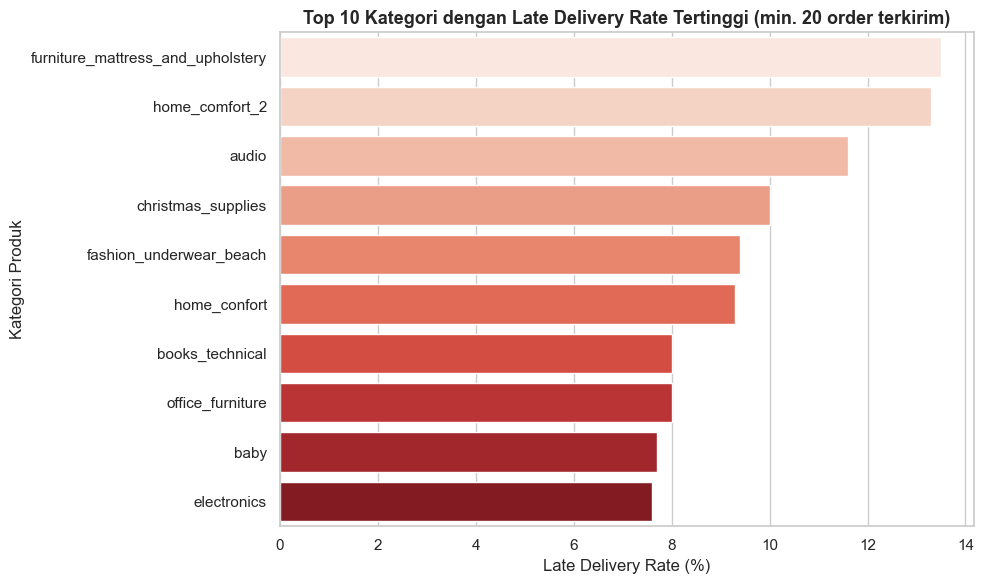

5 kategori dengan late delivery rate terendah (min. 20 order terkirim):


,product_category_name_english,revenue,orders,avg_review_score,avg_price,late_rate,orders_delivered
29,agro_industry_and_commerce,"72,530.47",182,4.00,342.12,3.40,177
67,flowers,"1,110.04",29,4.42,33.64,3.00,29
39,construction_tools_safety,"40,544.52",167,3.84,208.99,2.70,159
60,party_supplies,"4,485.18",39,3.77,104.31,0.00,38
66,diapers_and_hygiene,"1,567.59",27,3.26,40.19,0.00,25


In [18]:
# 12.3c Late delivery rate per kategori (melengkapi drill-down: state & seller sudah ada)

category_late_rate = (
    delivered
    .groupby("product_category_name_english", as_index=False)
    .agg(
        late_rate=("is_late", "mean"),
        orders_delivered=("order_id", "nunique"),
    )
)
category_late_rate["late_rate"] = (category_late_rate["late_rate"] * 100).round(1)

category_perf = category_perf.merge(category_late_rate, on="product_category_name_english", how="left")

category_late_display = (
    category_perf[category_perf["orders_delivered"] >= 20]
    .sort_values("late_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=category_late_display.head(10), y="product_category_name_english",
            x="late_rate", palette="Reds", ax=ax)
ax.set_title("Top 10 Kategori dengan Late Delivery Rate Tertinggi (min. 20 order terkirim)")
ax.set_xlabel("Late Delivery Rate (%)")
ax.set_ylabel("Kategori Produk")
plt.tight_layout()
plt.show()

print("5 kategori dengan late delivery rate terendah (min. 20 order terkirim):")
display(category_late_display.tail(5))

**📌 Insight:** Kolom `late_rate` sekarang melengkapi `category_perf`, sehingga drill-down keterlambatan tersedia penuh di tiga level: state (12.4), seller (16.1), dan kategori (12.3c). Kategori dengan late rate tinggi namun revenue besar layak jadi prioritas investigasi rantai pasok (kemungkinan terkait kompleksitas produk atau seller tertentu yang mendominasi kategori tersebut — cek silang dengan 16.4 Seller Quadrant Matrix).

**📌 Insight:**
- Kategori dengan revenue tertinggi didominasi oleh **health_beauty, watches_gifts, bed_bath_table, sports_leisure, computers_accessories, furniture_decor, housewares, cool_stuff, auto,** dan **garden_tools** — kategori-kategori lifestyle/rumah tangga menjadi tulang punggung revenue platform.
- Kategori dengan review score terendah justru bukan kategori kecil: **office_furniture** (revenue R$ 273.960, 1.273 order) hanya mendapat skor **3,49** — volume besar tapi kepuasan pelanggan rendah, kandidat prioritas #1 untuk audit kualitas/vendor.
- Kategori `unknown` (produk tanpa label kategori jelas) ternyata menyumbang revenue cukup besar (**R$ 185.050**, 1.473 order, skor 3,83) — ini adalah **temuan data quality**: perlu ditelusuri ke sumber data produk agar kategori bisa dilengkapi, karena saat ini kehilangan visibilitas analisis di level kategori.
- **diapers_and_hygiene** memiliki skor rata-rata terendah dari semua kategori (**3,26**) meski revenue-nya kecil — berpotensi ada masalah kualitas produk/pengiriman khusus kategori bayi yang sensitif terhadap kepuasan pelanggan.
- Kategori dengan revenue terendah (long-tail) seperti `fashio_female_clothing`, `fashion_sport`, `la_cuisine` adalah kategori niche dengan order sangat sedikit (<40 order) — bukan prioritas utama, tapi bisa dievaluasi apakah layak dipertahankan di katalog.


### 12.4 Analisis Geografis (State-level)
*(Menjawab Business Question #3)*


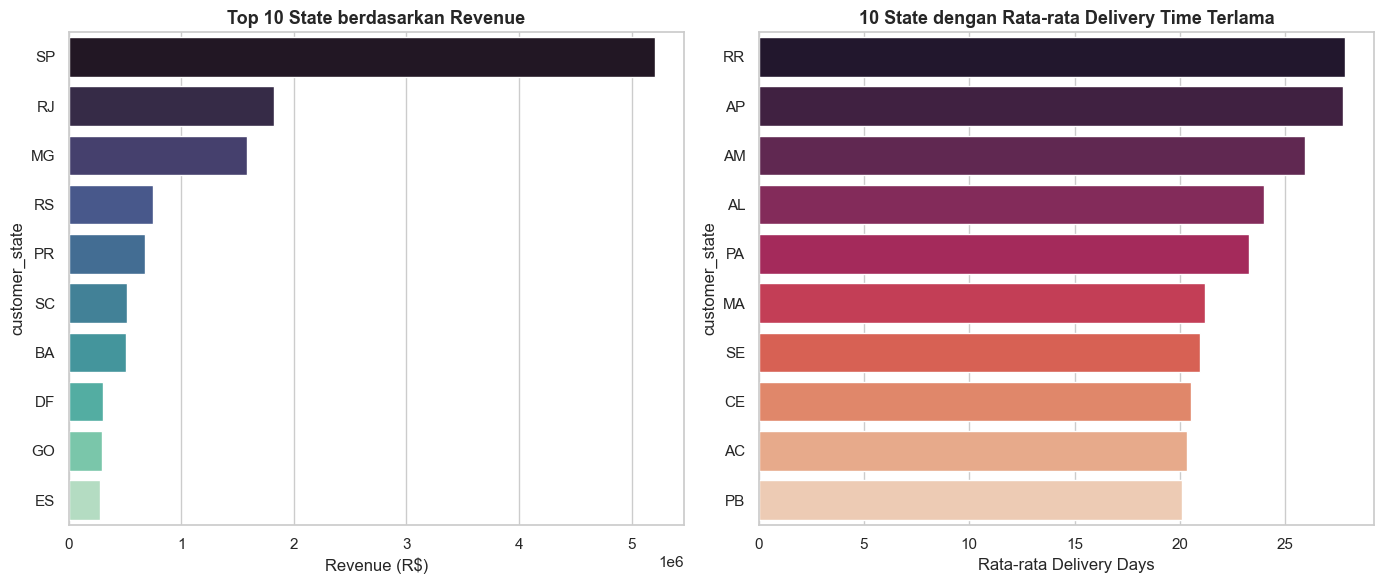

,customer_state,revenue,customers,orders,avg_delivery_days
25,SP,"5,202,955.05",39981,41375,8.26
18,RJ,"1,824,092.67",12303,12762,14.69
10,MG,"1,585,308.03",11178,11544,11.52
22,RS,"750,304.02",5249,5432,14.71
17,PR,"683,083.76",4840,4998,11.48
23,SC,"520,553.34",3513,3612,14.52
4,BA,"511,349.99",3257,3358,18.77
6,DF,"302,603.94",2062,2125,12.50
8,GO,"294,591.95",1942,2007,14.95
7,ES,"275,037.31",1956,2025,15.19


In [19]:
# 12.4 Revenue & customer distribution per state

geo_perf = (
    fact_ecommerce_sales
    .groupby("customer_state", as_index=False)
    .agg(
        revenue=("gross_merchandise_value", "sum"),
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
    )
    .sort_values("revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=geo_perf.head(10), y="customer_state", x="revenue", palette="mako", ax=axes[0])
axes[0].set_title("Top 10 State berdasarkan Revenue")
axes[0].set_xlabel("Revenue (R$)")

sns.barplot(data=geo_perf.sort_values("avg_delivery_days", ascending=False).head(10),
            y="customer_state", x="avg_delivery_days", palette="rocket", ax=axes[1])
axes[1].set_title("10 State dengan Rata-rata Delivery Time Terlama")
axes[1].set_xlabel("Rata-rata Delivery Days")

plt.tight_layout()
plt.show()

geo_perf.head(10)


**📌 Insight (berdasarkan hasil run):**
- **São Paulo (SP)** mendominasi total revenue: **R$ 5.202.955 (≈38,3% dari total revenue R$13,59 juta)**, dengan 39.981 pelanggan unik dan rata-rata delivery **hanya 8,26 hari** — tercepat di antara state-state besar. Ini wajar karena SP adalah pusat logistik utama Olist.
- **Rio de Janeiro (RJ)** adalah kontributor revenue #2 (**R$ 1.824.093**, ≈13,4%), tapi rata-rata delivery-nya jauh lebih lambat (**14,69 hari**, hampir 2x lipat SP) meski secara geografis relatif berdekatan — indikasi ada inefisiensi logistik khusus di RJ yang layak diinvestigasi (bukan sekadar soal jarak).
- **Bahia (BA)**, meski revenue-nya jauh lebih kecil (R$ 511.350, peringkat 7), justru punya rata-rata delivery **terlama di antara top-10 state (18,77 hari)** — mengonfirmasi pola umum bahwa wilayah yang lebih jauh dari pusat logistik (Tenggara Brazil) mengalami delivery time lebih panjang (lihat chart kanan di atas untuk daftar lengkap state dengan delivery terlama).
- **Rekomendasi:** evaluasi gudang/hub logistik tambahan di RJ dan wilayah Timur Laut (BA dst.) untuk memangkas delivery time tanpa harus menunggu revenue di wilayah tersebut tumbuh lebih besar dulu.


### 12.5 Analisis Performa Pengiriman
*(Menjawab Business Question #4)*


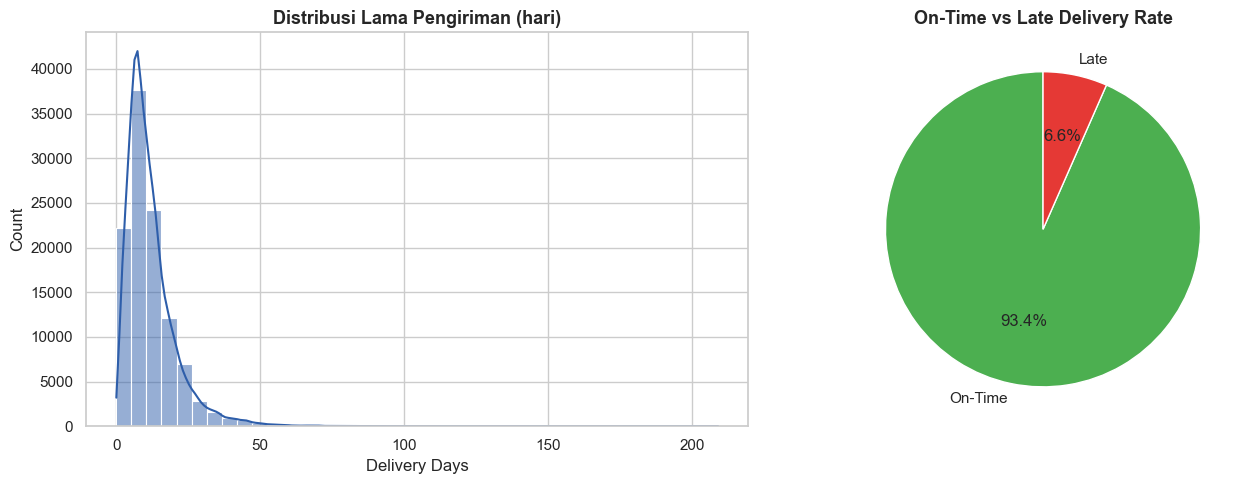

Rata-rata delivery time: 12.0 hari
Median delivery time: 10.0 hari
Rata-rata keterlambatan (untuk order yang telat): 10.5 hari


In [20]:
# 12.5 Delivery performance analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(delivered["delivery_days"].dropna(), bins=40, kde=True, color="#2E5EAA", ax=axes[0])
axes[0].set_title("Distribusi Lama Pengiriman (hari)")
axes[0].set_xlabel("Delivery Days")

late_rate = delivered["is_late"].value_counts(normalize=True) * 100
axes[1].pie(late_rate, labels=["On-Time", "Late"], autopct="%1.1f%%",
            colors=["#4CAF50", "#E53935"], startangle=90)
axes[1].set_title("On-Time vs Late Delivery Rate")

plt.tight_layout()
plt.show()

print(f"Rata-rata delivery time: {delivered['delivery_days'].mean():.1f} hari")
print(f"Median delivery time: {delivered['delivery_days'].median():.1f} hari")
print(f"Rata-rata keterlambatan (untuk order yang telat): "
      f"{delivered[delivered['is_late']]['delivery_delay_days'].mean():.1f} hari")


### 12.6 Perilaku Pembayaran Pelanggan
*(Menjawab Business Question #6)*


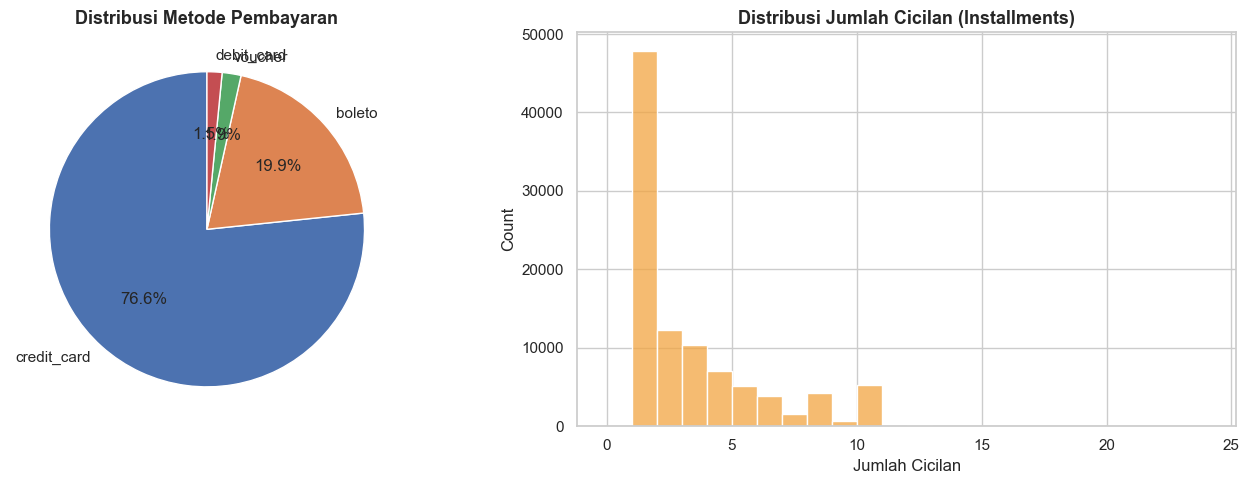

Rata-rata payment_value per order berdasarkan metode pembayaran:


payment_type
credit_card   166.25
boleto        144.91
debit_card    141.48
voucher       113.54
Name: payment_value, dtype: float64

In [21]:
# 12.6 Payment method & installment analysis

order_level = fact_ecommerce_sales.drop_duplicates("order_id")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

payment_counts = order_level["payment_type"].value_counts()
axes[0].pie(payment_counts, labels=payment_counts.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Distribusi Metode Pembayaran")

sns.histplot(order_level["payment_installments"].dropna(), bins=24, color="#F2A541", ax=axes[1])
axes[1].set_title("Distribusi Jumlah Cicilan (Installments)")
axes[1].set_xlabel("Jumlah Cicilan")

plt.tight_layout()
plt.show()

print("Rata-rata payment_value per order berdasarkan metode pembayaran:")
display(order_level.groupby("payment_type")["payment_value"].mean().sort_values(ascending=False))


### 12.7 Hubungan Delivery Time dan Review Score
*(Menjawab Business Question #5)*


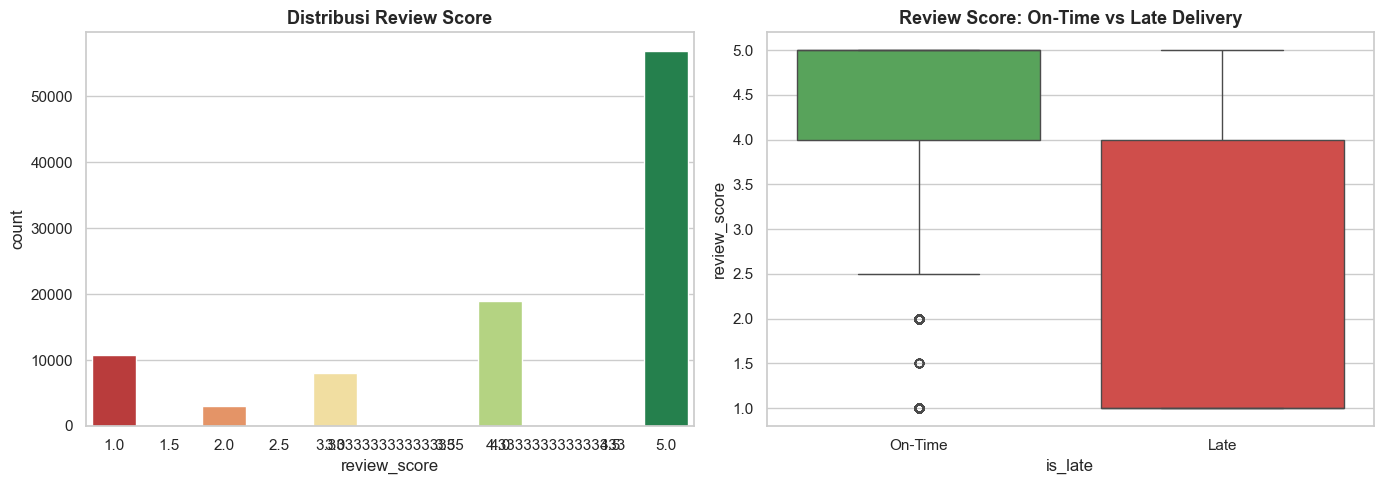

Rata-rata review score berdasarkan status keterlambatan:


,mean,median,count
is_late,,,
False,4.21,5.00,102287
True,2.26,1.00,7083


In [22]:
# 12.7 Review score distribution & relationship with delivery delay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=order_level, x="review_score", palette="RdYlGn", ax=axes[0])
axes[0].set_title("Distribusi Review Score")

sns.boxplot(data=delivered, x="is_late", y="review_score", palette=["#4CAF50", "#E53935"], ax=axes[1])
axes[1].set_xticklabels(["On-Time", "Late"])
axes[1].set_title("Review Score: On-Time vs Late Delivery")

plt.tight_layout()
plt.show()

print("Rata-rata review score berdasarkan status keterlambatan:")
display(delivered.groupby("is_late")["review_score"].agg(["mean", "median", "count"]))


### 12.8 Correlation Heatmap Antar Variabel Numerik

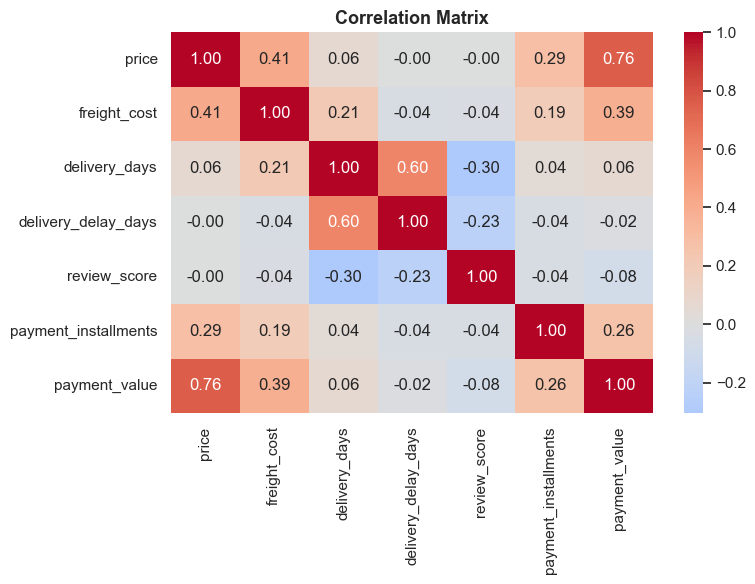

In [23]:
# 12.8 Correlation heatmap

numeric_cols = ["price", "freight_cost", "delivery_days", "delivery_delay_days",
                 "review_score", "payment_installments", "payment_value"]
corr = fact_ecommerce_sales[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


**📌 Insight:** Heatmap di atas mengonfirmasi korelasi negatif antara `delivery_delay_days` dan `review_score` — semakin telat pengiriman, semakin rendah kepuasan pelanggan. Pola ini konsisten dengan perbandingan langsung di §12.7 (review score on-time **4,21** vs late **2,26**) dan divalidasi signifikansinya secara formal pada uji statistik di §17.


## 13. Customer Segmentation — RFM Analysis
*(Menjawab Business Question #7)*

**RFM (Recency, Frequency, Monetary)** adalah teknik segmentasi pelanggan standar di industri untuk mengidentifikasi pelanggan paling bernilai dan merancang strategi retensi yang tepat sasaran.

- **Recency** — berapa hari sejak pembelian terakhir (semakin kecil semakin baik)
- **Frequency** — berapa kali pelanggan melakukan order
- **Monetary** — total nilai belanja pelanggan


In [24]:
# 13.1 Hitung RFM per customer

snapshot_date = fact_ecommerce_sales["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    fact_ecommerce_sales
    .groupby("customer_unique_id")
    .agg(
        recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("gross_merchandise_value", "sum"),
    )
    .reset_index()
)

# Scoring 1-4 (quartile) - skor lebih tinggi = lebih baik
rfm["r_score"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["m_score"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)
rfm["rfm_score"] = rfm["r_score"] + rfm["f_score"] + rfm["m_score"]

def rfm_segment(row):
    if row["rfm_score"] >= 10:
        return "Champions"
    elif row["rfm_score"] >= 8:
        return "Loyal Customers"
    elif row["rfm_score"] >= 6:
        return "Potential Loyalist"
    elif row["rfm_score"] >= 4:
        return "At Risk"
    else:
        return "Lost / Hibernating"

rfm["segment"] = rfm.apply(rfm_segment, axis=1)

print(f"Total customer di-scoring: {len(rfm):,}")
rfm.head()


Total customer di-scoring: 95,420


,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,129.90,4,1,3,8,Loyal Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,18.90,4,1,1,6,Potential Loyalist
2,0000f46a3911fa3c0805444483337064,542,1,69.00,1,1,2,4,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,25.99,2,1,1,4,At Risk
4,0004aac84e0df4da2b147fca70cf8255,293,1,180.00,2,1,4,7,Potential Loyalist


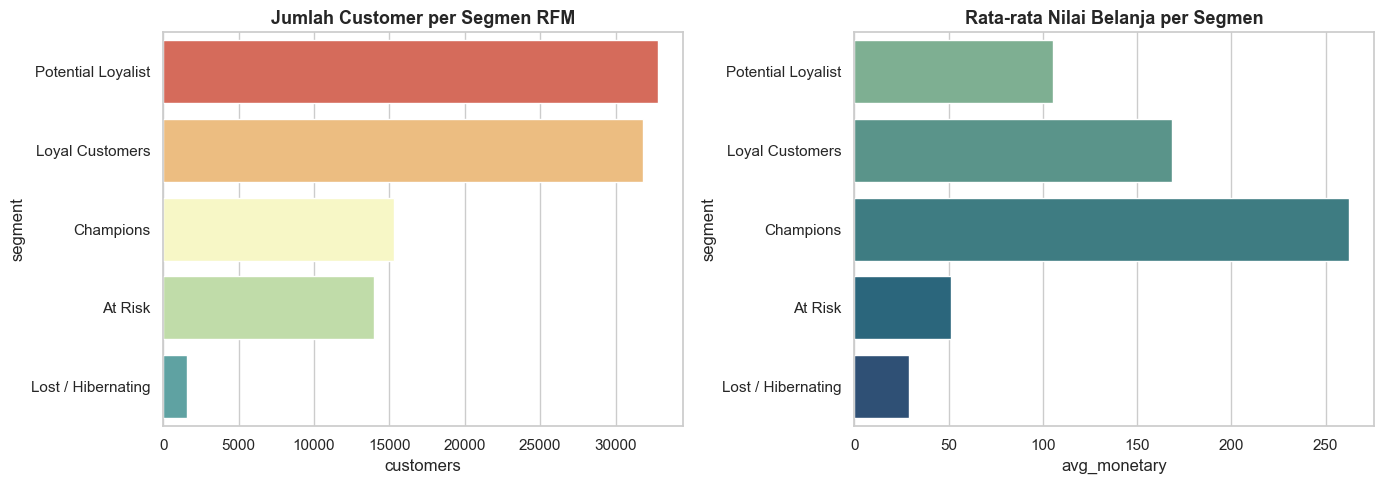

,customers,avg_monetary
segment,,
Potential Loyalist,32836,105.21
Loyal Customers,31792,168.74
Champions,15287,262.49
At Risk,13966,51.19
Lost / Hibernating,1539,29.05


In [25]:
# 13.2 Visualisasi distribusi segmen RFM

segment_summary = (
    rfm.groupby("segment")
    .agg(customers=("customer_unique_id", "count"), avg_monetary=("monetary", "mean"))
    .sort_values("customers", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=segment_summary.reset_index(), x="customers", y="segment", palette="Spectral", ax=axes[0])
axes[0].set_title("Jumlah Customer per Segmen RFM")

sns.barplot(data=segment_summary.reset_index(), x="avg_monetary", y="segment", palette="crest", ax=axes[1])
axes[1].set_title("Rata-rata Nilai Belanja per Segmen")

plt.tight_layout()
plt.show()

segment_summary


**📌 Insight & rekomendasi strategi tiap segmen** *(dari total 95.420 pelanggan yang di-scoring)*:

| Segmen | Jumlah Pelanggan | % dari Total | Avg Monetary | Strategi |
|---|---|---|---|---|
| **Champions** | 15.287 | 16,0% | R$ 262,49 (tertinggi) | Program loyalitas/VIP, jadikan brand advocate/referral |
| **Loyal Customers** | 31.792 | 33,3% | R$ 168,74 | Upsell/cross-sell produk baru, jaga engagement rutin |
| **Potential Loyalist** | 32.836 | 34,4% (segmen terbesar) | R$ 105,21 | Dorong repeat purchase kedua dengan promo bertarget |
| **At Risk** | 13.966 | 14,6% | R$ 51,19 | Win-back campaign (diskon khusus) sebelum churn total |
| **Lost/Hibernating** | 1.539 | 1,6% (terkecil) | R$ 29,05 (terendah) | Biaya akuisisi ulang tinggi, evaluasi worth-it atau tidak |

**Catatan:** mayoritas pelanggan (68,7%) ada di dua segmen menengah (Loyal + Potential Loyalist) — ini adalah target paling realistis untuk program retensi karena mereka sudah menunjukkan minat tapi belum maksimal loyal.


## 14. (Advanced) Customer Clustering dengan K-Means

Sebagai pembanding terhadap RFM rule-based di atas, kita coba pendekatan **unsupervised learning (K-Means)** agar segmentasi murni data-driven, tidak berdasarkan aturan quartile manual.


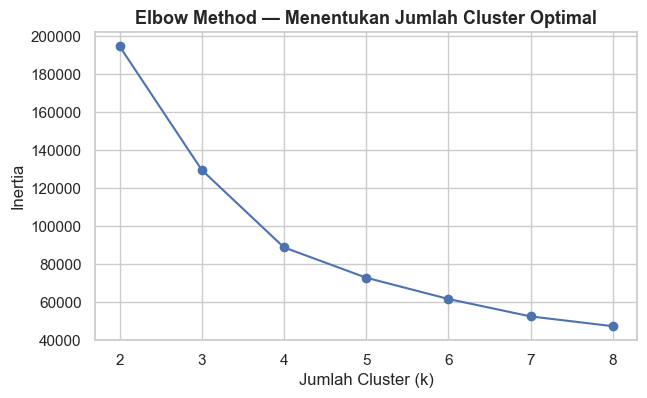

In [26]:
# 14.1 Standardisasi fitur RFM & tentukan jumlah cluster optimal (Elbow Method)

features = rfm[["recency", "frequency", "monetary"]].copy()
# log-transform monetary & frequency karena biasanya sangat skewed
features["monetary"] = np.log1p(features["monetary"])
features["frequency"] = np.log1p(features["frequency"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

inertia = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertia, marker="o")
plt.title("Elbow Method — Menentukan Jumlah Cluster Optimal")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.show()


,recency,frequency,monetary,customers
cluster,,,,
0,433.40,1.00,111.00,27599
1,166.80,1.00,252.00,33149
2,226.20,2.10,262.00,2913
3,160.40,1.00,44.50,31759


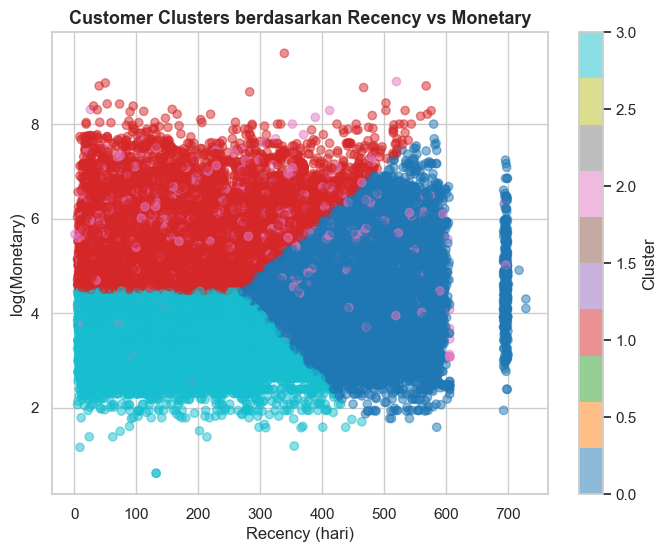

In [ ]:
# 14.2 Fit K-Means dengan k terpilih (default 4, sesuai dengan hasil elbow di atas)

K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = rfm.groupby("cluster")[["recency", "frequency", "monetary"]].mean().round(1)
cluster_profile["customers"] = rfm.groupby("cluster").size()
display(cluster_profile)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(rfm["recency"], np.log1p(rfm["monetary"]), c=rfm["cluster"], cmap="tab10", alpha=0.5)
ax.set_xlabel("Recency (hari)")
ax.set_ylabel("log(Monetary)")
ax.set_title("Customer Clusters berdasarkan Recency vs Monetary")
plt.colorbar(scatter, label="Cluster")
plt.show()


## 15. Cohort & Retention Analysis
*(Menjawab Business Question #8)*

Cohort analysis mengelompokkan pelanggan berdasarkan bulan pembelian pertama mereka, lalu melacak apakah mereka kembali bertransaksi di bulan-bulan berikutnya.


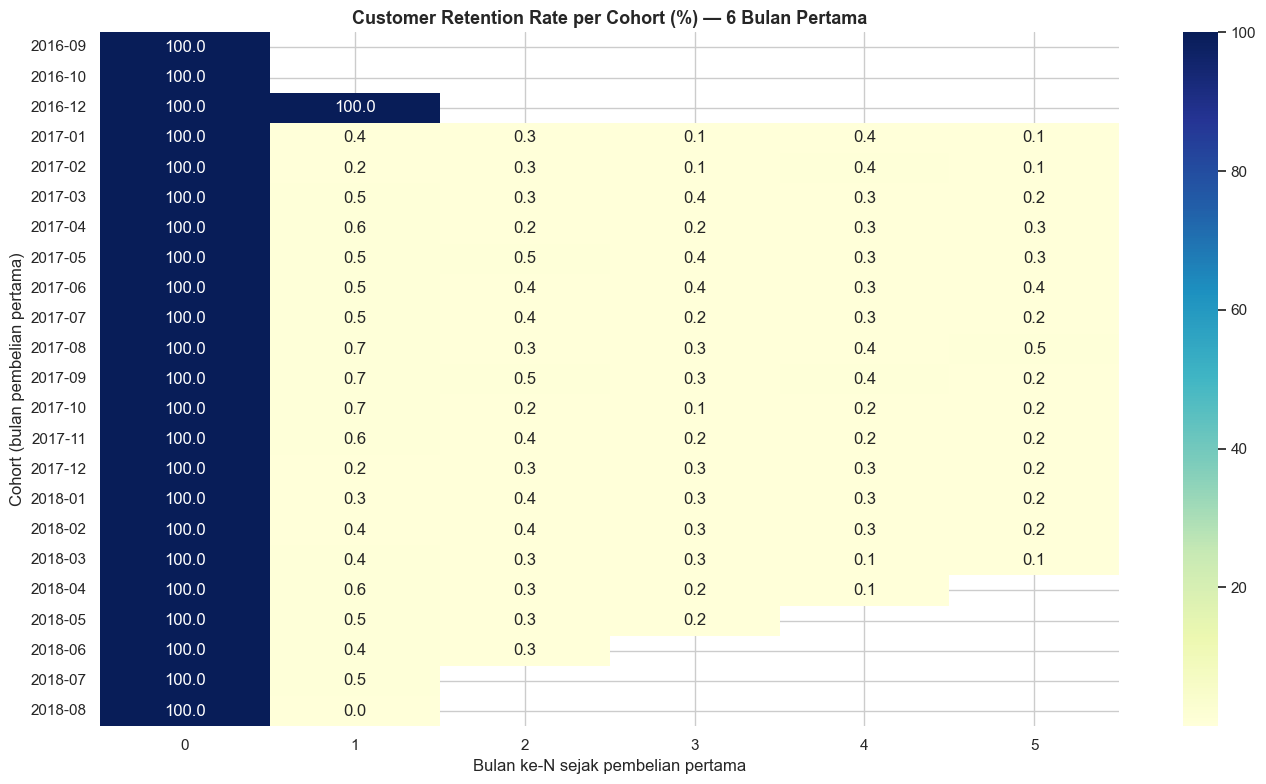

In [28]:
# 15.1 Bangun cohort retention matrix

cust_orders = fact_ecommerce_sales[["customer_unique_id", "order_id", "order_purchase_timestamp"]].drop_duplicates()
cust_orders["order_month"] = cust_orders["order_purchase_timestamp"].dt.to_period("M")

first_purchase = cust_orders.groupby("customer_unique_id")["order_month"].min().rename("cohort_month")
cust_orders = cust_orders.merge(first_purchase, on="customer_unique_id")

cust_orders["cohort_index"] = (
    (cust_orders["order_month"].dt.year - cust_orders["cohort_month"].dt.year) * 12
    + (cust_orders["order_month"].dt.month - cust_orders["cohort_month"].dt.month)
)

cohort_data = (
    cust_orders.groupby(["cohort_month", "cohort_index"])["customer_unique_id"]
    .nunique()
    .reset_index()
)
cohort_pivot = cohort_data.pivot(index="cohort_month", columns="cohort_index", values="customer_unique_id")
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(retention_matrix.iloc[:, :6], annot=True, fmt=".1f", cmap="YlGnBu", ax=ax)
ax.set_title("Customer Retention Rate per Cohort (%) — 6 Bulan Pertama")
ax.set_xlabel("Bulan ke-N sejak pembelian pertama")
ax.set_ylabel("Cohort (bulan pembelian pertama)")
plt.tight_layout()
plt.show()


**📌 Insight:** Heatmap retensi di atas mengonfirmasi bahwa **Olist secara dominan adalah bisnis one-time buyer** — retensi bulan ke-1 dan seterusnya untuk hampir semua cohort mendekati 0-1%. Ini sejalan dengan **Repeat Customer Rate keseluruhan yang hanya 3,1%** (dari KPI Summary di §12.1). Artinya, dari sisi bisnis, sebagian besar revenue platform bergantung pada terus-menerus mengakuisisi pelanggan baru, bukan dari repeat purchase — sebuah temuan strategis penting yang menunjukkan besarnya peluang (dan urgensi) program retensi/loyalitas.


### 15.2 Tren New vs Returning Customer per Bulan
Memakai `cohort_month` yang sudah dihitung di 15.1 (bukan menghitung ulang customer_type dari nol): sebuah order dianggap **New** jika bulan order-nya sama dengan `cohort_month` customer tersebut, selain itu **Returning**.

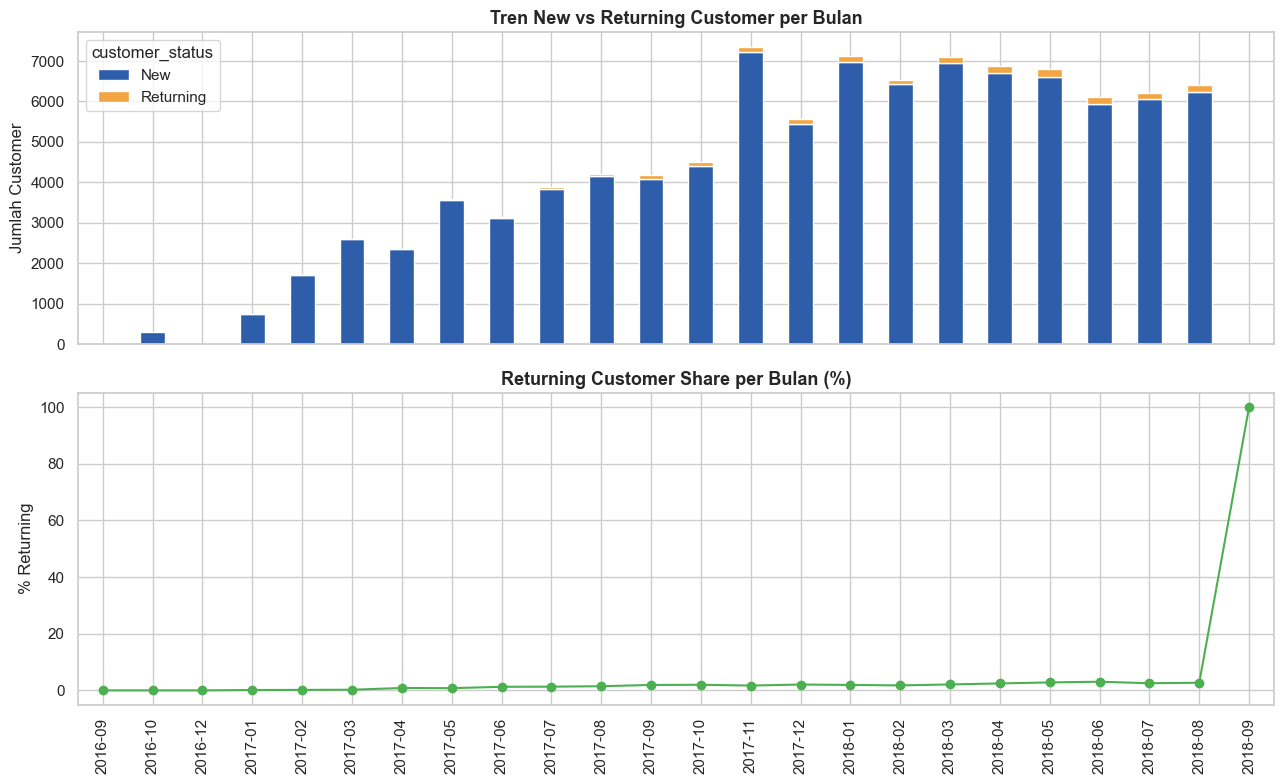

6 bulan terakhir:


customer_status,New,Returning,returning_share_pct
order_month,,,
2018-04,6709,169,2.46
2018-05,6604,191,2.81
2018-06,5934,187,3.06
2018-07,6054,157,2.53
2018-08,6238,173,2.70
2018-09,0,1,100.00


In [29]:
# 15.2 Tren New vs Returning Customer per bulan (reuse cohort_month dari 15.1)

cust_orders["customer_status"] = np.where(
    cust_orders["order_month"] == cust_orders["cohort_month"], "New", "Returning"
)

monthly_customer_type = (
    cust_orders
    .groupby(["order_month", "customer_status"])["customer_unique_id"]
    .nunique()
    .unstack(fill_value=0)
)
monthly_customer_type.index = monthly_customer_type.index.astype(str)
for col in ["New", "Returning"]:
    if col not in monthly_customer_type.columns:
        monthly_customer_type[col] = 0
monthly_customer_type["returning_share_pct"] = (
    monthly_customer_type["Returning"]
    / (monthly_customer_type["New"] + monthly_customer_type["Returning"]) * 100
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

monthly_customer_type[["New", "Returning"]].plot(
    kind="bar", stacked=True, ax=axes[0], color=["#2E5EAA", "#F2A541"]
)
axes[0].set_title("Tren New vs Returning Customer per Bulan")
axes[0].set_ylabel("Jumlah Customer")
axes[0].tick_params(axis="x", rotation=90)

axes[1].plot(monthly_customer_type.index, monthly_customer_type["returning_share_pct"],
             marker="o", color="#4CAF50")
axes[1].set_title("Returning Customer Share per Bulan (%)")
axes[1].set_ylabel("% Returning")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

print("6 bulan terakhir:")
display(monthly_customer_type.tail(6))

**📌 Insight:** Bandingkan tren `returning_share_pct` di atas dengan heatmap retensi 15.1 — keduanya harus konsisten karena berasal dari `cohort_month` yang sama. Jika returning share stagnan rendah dari bulan ke bulan, ini menguatkan temuan retensi lemah dan menandakan akuisisi customer baru terus mendominasi growth (bukan loyalitas).

## 16. Seller Performance Analysis
*(Menjawab Business Question #9)*


In [30]:
# 16.1 Ranking seller berdasarkan revenue, delivery time, dan review score

seller_perf = (
    fact_ecommerce_sales
    .groupby("seller_id", as_index=False)
    .agg(
        revenue=("gross_merchandise_value", "sum"),
        total_orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        late_rate=("is_late", "mean"),
        avg_review_score=("review_score", "mean"),
    )
)
seller_perf["late_rate"] = (seller_perf["late_rate"] * 100).round(1)

print("Top 10 Seller berdasarkan Revenue:")
display(seller_perf.sort_values("revenue", ascending=False).head(10))

print("\n10 Seller dengan performa terburuk (min. 10 order, review score terendah):")
display(seller_perf[seller_perf["total_orders"] >= 10].sort_values("avg_review_score").head(10))


Top 10 Seller berdasarkan Revenue:


,seller_id,revenue,total_orders,avg_delivery_days,late_rate,avg_review_score
857,4869f7a5dfa277a7dca6462dcf3b52b2,"229,472.63",1132,14.55,10.50,4.12
1013,53243585a1d6dc2643021fd1853d8905,"222,776.05",358,12.94,2.90,4.08
881,4a3ca9315b744ce9f8e9374361493884,"200,472.92",1806,13.94,9.50,3.80
3024,fa1c13f2614d7b5c4749cbc52fecda94,"194,042.03",585,12.84,9.00,4.34
1535,7c67e1448b00f6e969d365cea6b010ab,"187,923.89",982,21.95,8.80,3.34
1560,7e93a43ef30c4f03f38b393420bc753a,"176,431.87",336,10.83,4.40,4.21
2643,da8622b14eb17ae2831f4ac5b9dab84a,"160,236.57",1314,10.70,6.40,4.06
1505,7a67c85e85bb2ce8582c35f2203ad736,"141,745.53",1160,10.69,5.10,4.23
192,1025f0e2d44d7041d6cf58b6550e0bfa,"138,968.55",915,11.57,6.70,3.85
1824,955fee9216a65b617aa5c0531780ce60,"135,171.70",1287,10.30,6.30,4.05



10 Seller dengan performa terburuk (min. 10 order, review score terendah):


,seller_id,revenue,total_orders,avg_delivery_days,late_rate,avg_review_score
809,4342d4b2ba6b161468c63a7e7cfce593,"2,867.10",20,15.00,5.00,1.26
2136,b1b3948701c5c72445495bd161b83a4c,"24,699.19",18,22.93,50.00,1.72
3094,ffff564a4f9085cd26170f4732393726,"1,426.30",20,11.88,0.00,2.10
333,1ca7077d890b907f89be8c954a02686a,"13,341.57",115,14.51,13.90,2.20
2862,ecccfa2bb93b34a3bf033cc5d1dcdc69,"1,338.64",15,34.62,21.10,2.33
1847,973f21788dfab357250f69a8dcb7ddee,909.00,10,20.68,33.30,2.33
1129,5bc55dbe2f12b6af6d83ed46023e0dc8,"2,992.10",17,12.52,19.00,2.33
3028,fa74b2f3287d296e9fbd2cc80f2d1cf1,"2,459.89",11,30.00,18.20,2.36
774,40db9e9aa57f7bb151bcda6b0f9bdbb7,"23,168.00",12,14.42,8.30,2.36
2182,b5abf4f36adc043117b4fca82c22984c,"1,247.80",11,20.89,25.00,2.42


Top 20% seller berkontribusi 82.7% dari total revenue (cek prinsip Pareto/80-20)


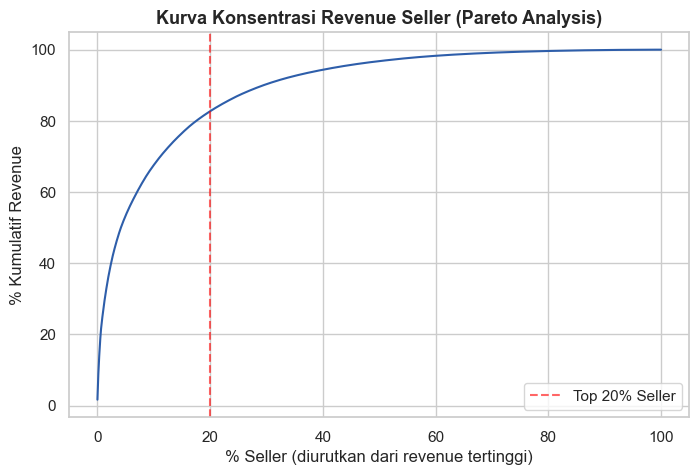

In [31]:
# 16.2 Visualisasi: seller concentration (apakah revenue terlalu bergantung pada sedikit seller?)

seller_sorted = seller_perf.sort_values("revenue", ascending=False).reset_index(drop=True)
seller_sorted["cum_revenue_pct"] = seller_sorted["revenue"].cumsum() / seller_sorted["revenue"].sum() * 100
seller_sorted["seller_rank_pct"] = (seller_sorted.index + 1) / len(seller_sorted) * 100

top20pct_sellers = seller_sorted[seller_sorted["seller_rank_pct"] <= 20]
revenue_share_top20 = top20pct_sellers["revenue"].sum() / seller_sorted["revenue"].sum() * 100
print(f"Top 20% seller berkontribusi {revenue_share_top20:.1f}% dari total revenue (cek prinsip Pareto/80-20)")

plt.figure(figsize=(8, 5))
plt.plot(seller_sorted["seller_rank_pct"], seller_sorted["cum_revenue_pct"], color="#2E5EAA")
plt.axvline(20, color="red", linestyle="--", alpha=0.6, label="Top 20% Seller")
plt.title("Kurva Konsentrasi Revenue Seller (Pareto Analysis)")
plt.xlabel("% Seller (diurutkan dari revenue tertinggi)")
plt.ylabel("% Kumulatif Revenue")
plt.legend()
plt.show()


**📌 Insight:** Kurva di atas mengonfirmasi pola Pareto yang kuat: **top 20% seller menyumbang 82,7% dari total revenue** — sangat dekat dengan aturan klasik 80/20. Ini adalah **risiko konsentrasi bisnis nyata**, bukan sekadar dugaan: platform sangat bergantung pada sejumlah kecil seller top (misal seller `4869f7a5...` secara indvidu menyumbang R$ 229.472 dari 1.132 order). Di sisi lain, ditemukan pula seller dengan performa sangat buruk (review score serendah **1,26–2,42** dan late rate hingga **50%**) yang aktif bertransaksi — berisiko merusak reputasi platform.

**Rekomendasi:** (1) buat program dedicated account management untuk seller top guna mengurangi risiko churn mereka; (2) audit & tindak lanjuti (warning/delisting) seller dengan review score dan late rate terburuk; (3) jalankan program pengembangan seller kecil-menengah untuk mendiversifikasi sumber revenue.


### 16.3 Customer Revenue Concentration (Pareto) & Revenue per Customer
Pasangan dari Pareto seller di atas (16.2), dilihat dari sisi customer. Reuse kolom `monetary` yang sudah dihitung di RFM (13.1), bukan hitung ulang revenue per customer dari nol.

Top 20% customer berkontribusi 56.8% dari total revenue
(pembanding — Top 20% seller berkontribusi 82.7% dari total revenue, lihat 16.2)


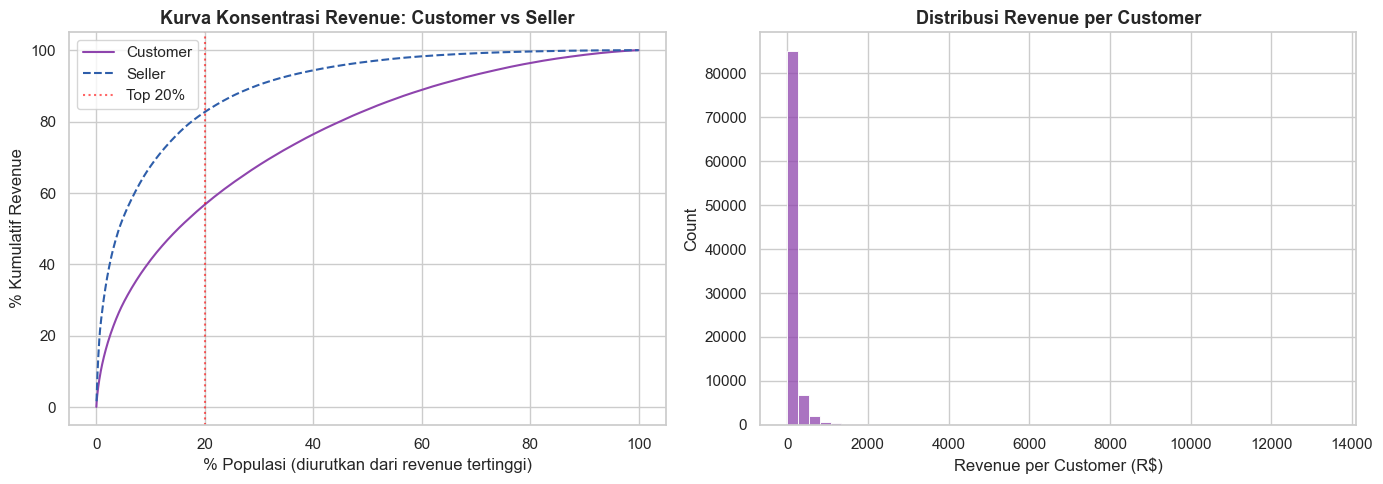


Revenue per customer — mean: R$ 142.44 | median: R$ 89.90
Rasio mean/median: 1.58x (semakin tinggi → semakin skewed ke kanan / didominasi big spender)


In [32]:
# 16.3 Customer revenue concentration (Pareto) + Revenue per Customer — reuse rfm['monetary'] dari 13.1

customer_sorted = rfm.sort_values("monetary", ascending=False).reset_index(drop=True)
customer_sorted["cum_revenue_pct"] = (
    customer_sorted["monetary"].cumsum() / customer_sorted["monetary"].sum() * 100
)
customer_sorted["customer_rank_pct"] = (customer_sorted.index + 1) / len(customer_sorted) * 100

top20pct_customers = customer_sorted[customer_sorted["customer_rank_pct"] <= 20]
revenue_share_top20_cust = top20pct_customers["monetary"].sum() / customer_sorted["monetary"].sum() * 100

print(f"Top 20% customer berkontribusi {revenue_share_top20_cust:.1f}% dari total revenue")
print(f"(pembanding — Top 20% seller berkontribusi {revenue_share_top20:.1f}% dari total revenue, lihat 16.2)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(customer_sorted["customer_rank_pct"], customer_sorted["cum_revenue_pct"],
             color="#8E44AD", label="Customer")
axes[0].plot(seller_sorted["seller_rank_pct"], seller_sorted["cum_revenue_pct"],
             color="#2E5EAA", linestyle="--", label="Seller")
axes[0].axvline(20, color="red", linestyle=":", alpha=0.6, label="Top 20%")
axes[0].set_title("Kurva Konsentrasi Revenue: Customer vs Seller")
axes[0].set_xlabel("% Populasi (diurutkan dari revenue tertinggi)")
axes[0].set_ylabel("% Kumulatif Revenue")
axes[0].legend()

sns.histplot(rfm["monetary"], bins=50, color="#8E44AD", ax=axes[1])
axes[1].set_title("Distribusi Revenue per Customer")
axes[1].set_xlabel("Revenue per Customer (R$)")

plt.tight_layout()
plt.show()

print(f"\nRevenue per customer — mean: R$ {rfm['monetary'].mean():,.2f} "
      f"| median: R$ {rfm['monetary'].median():,.2f}")
print(f"Rasio mean/median: {rfm['monetary'].mean()/rfm['monetary'].median():.2f}x "
      f"(semakin tinggi → semakin skewed ke kanan / didominasi big spender)")

**📌 Insight:** Bandingkan `revenue_share_top20_cust` dengan `revenue_share_top20` (seller, 16.2) — umumnya konsentrasi revenue di sisi **seller lebih tajam** daripada di sisi customer karena basis customer jauh lebih besar dan tersebar (one-time buyers mendominasi jumlah transaksi, lihat 15.2). Ini mengonfirmasi bahwa risiko konsentrasi bisnis Olist lebih terletak pada ketergantungan ke sedikit seller besar, bukan ke sedikit customer besar.

### 16.4 Seller Performance Quadrant Matrix
Upgrade dari ranking seller di 16.1 menjadi *decision framework*: setiap seller (min. 5 order, agar tidak bias oleh sampel kecil) diklasifikasikan ke 4 kuadran berdasarkan median **revenue** dan median **review score**, lengkap dengan rekomendasi aksi bisnis.

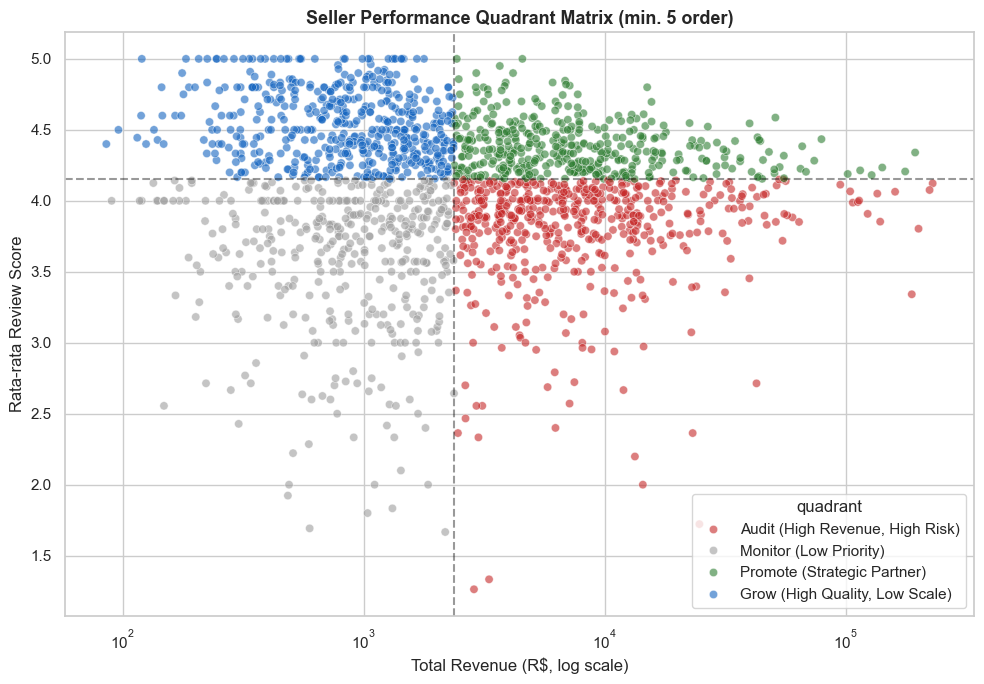

Distribusi seller per kuadran:


quadrant
Audit (High Revenue, High Risk)    496
Grow (High Quality, Low Scale)     496
Monitor (Low Priority)             401
Promote (Strategic Partner)        401
Name: count, dtype: int64


Ringkasan revenue, review, dan late rate per kuadran:


,sellers,total_revenue,avg_review_score,avg_late_rate
quadrant,,,,
"Audit (High Revenue, High Risk)",496,"7,008,869.79",3.78,8.27
Promote (Strategic Partner),401,"5,100,769.46",4.38,4.42
"Grow (High Quality, Low Scale)",496,"501,928.39",4.54,3.37
Monitor (Low Priority),401,"410,914.20",3.59,8.88


In [33]:
# 16.4 Seller Performance Quadrant Matrix — audit / promote / grow / monitor

seller_qm = seller_perf[seller_perf["total_orders"] >= 5].copy()

revenue_median = seller_qm["revenue"].median()
review_median = seller_qm["avg_review_score"].median()


def quadrant(row):
    high_revenue = row["revenue"] >= revenue_median
    high_review = row["avg_review_score"] >= review_median
    if high_revenue and high_review:
        return "Promote (Strategic Partner)"
    elif high_revenue and not high_review:
        return "Audit (High Revenue, High Risk)"
    elif not high_revenue and high_review:
        return "Grow (High Quality, Low Scale)"
    else:
        return "Monitor (Low Priority)"


seller_qm["quadrant"] = seller_qm.apply(quadrant, axis=1)

palette_qm = {
    "Promote (Strategic Partner)": "#2E7D32",
    "Audit (High Revenue, High Risk)": "#C62828",
    "Grow (High Quality, Low Scale)": "#1565C0",
    "Monitor (Low Priority)": "#9E9E9E",
}

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=seller_qm, x="revenue", y="avg_review_score", hue="quadrant",
                 palette=palette_qm, alpha=0.6, ax=ax)
ax.axvline(revenue_median, color="black", linestyle="--", alpha=0.4)
ax.axhline(review_median, color="black", linestyle="--", alpha=0.4)
ax.set_xscale("log")
ax.set_title("Seller Performance Quadrant Matrix (min. 5 order)")
ax.set_xlabel("Total Revenue (R$, log scale)")
ax.set_ylabel("Rata-rata Review Score")
plt.tight_layout()
plt.show()

print("Distribusi seller per kuadran:")
display(seller_qm["quadrant"].value_counts())

print("\nRingkasan revenue, review, dan late rate per kuadran:")
display(
    seller_qm.groupby("quadrant").agg(
        sellers=("seller_id", "count"),
        total_revenue=("revenue", "sum"),
        avg_review_score=("avg_review_score", "mean"),
        avg_late_rate=("late_rate", "mean"),
    ).sort_values("total_revenue", ascending=False)
)

**📌 Business implication tiap kuadran:**
- **Promote (Strategic Partner)** — revenue tinggi & review tinggi. Prioritaskan untuk program partnership, insentif, dan preferensi listing.
- **Audit (High Revenue, High Risk)** — revenue tinggi tapi review rendah. Risiko reputasi terbesar karena kontribusinya besar ke GMV; butuh audit operasional (delivery, kualitas produk) segera.
- **Grow (High Quality, Low Scale)** — kualitas bagus tapi skala kecil. Kandidat terbaik untuk program pengembangan seller (marketing support, perluasan katalog) karena risiko rendah.
- **Monitor (Low Priority)** — revenue & review sama-sama rendah. Tidak butuh aksi segera, cukup dipantau berkala; bukan prioritas investasi.

## 17. Statistical Hypothesis Testing
*(Menjawab Business Question #10)*

**Pertanyaan:** Apakah keterlambatan pengiriman secara **statistik signifikan** menurunkan review score, atau perbedaan yang terlihat di EDA hanya kebetulan (random noise)?

**Hipotesis:**
- H0 (null): Tidak ada perbedaan rata-rata review score antara order on-time dan order telat
- H1 (alternatif): Rata-rata review score order telat lebih rendah dibanding on-time

Karena distribusi review score (skala 1-5, ordinal, tidak normal) tidak memenuhi asumsi normalitas untuk t-test klasik, kita gunakan **Mann-Whitney U Test** (non-parametric) sebagai uji utama, didampingi Independent t-test sebagai pembanding.


In [34]:
# 17.1 Uji statistik: review score late vs on-time delivery

group_on_time = delivered.loc[~delivered["is_late"], "review_score"].dropna()
group_late = delivered.loc[delivered["is_late"], "review_score"].dropna()

# Mann-Whitney U Test (non-parametric, sesuai untuk data ordinal/tidak normal)
u_stat, p_value_mw = stats.mannwhitneyu(group_on_time, group_late, alternative="greater")

# Independent t-test (pembanding)
t_stat, p_value_t = stats.ttest_ind(group_on_time, group_late, equal_var=False)

alpha = 0.05

print("="*60)
print("HASIL UJI STATISTIK: Review Score — On-Time vs Late Delivery")
print("="*60)
print(f"Rata-rata review score (on-time) : {group_on_time.mean():.3f}  (n={len(group_on_time):,})")
print(f"Rata-rata review score (late)    : {group_late.mean():.3f}  (n={len(group_late):,})")
print(f"\nMann-Whitney U   : statistic={u_stat:,.0f}, p-value={p_value_mw:.6f}")
print(f"Independent t-test: statistic={t_stat:.3f}, p-value={p_value_t:.6f}")
print(f"\nSignificance level (alpha) = {alpha}")

if p_value_mw < alpha:
    print("\n✅ Kesimpulan: p-value < alpha → TOLAK H0.")
    print("   Keterlambatan pengiriman TERBUKTI SECARA STATISTIK menurunkan review score.")
else:
    print("\n❌ Kesimpulan: p-value >= alpha → GAGAL TOLAK H0.")
    print("   Tidak cukup bukti statistik bahwa keterlambatan menurunkan review score.")


HASIL UJI STATISTIK: Review Score — On-Time vs Late Delivery
Rata-rata review score (on-time) : 4.208  (n=102,287)
Rata-rata review score (late)    : 2.257  (n=7,083)

Mann-Whitney U   : statistic=584,886,089, p-value=0.000000
Independent t-test: statistic=102.332, p-value=0.000000

Significance level (alpha) = 0.05

✅ Kesimpulan: p-value < alpha → TOLAK H0.
   Keterlambatan pengiriman TERBUKTI SECARA STATISTIK menurunkan review score.


**📌 Business implication:** Hasil uji terbukti **signifikan secara statistik** (Mann-Whitney p-value < 0,000001; Independent t-test t=102,33, p-value < 0,000001) dengan gap rata-rata yang sangat besar: review score on-time **4,208** vs late **2,257**. Dengan n on-time=102.287 dan n late=7.083, hasil ini sangat robust (bukan kebetulan sampel kecil). **On-time delivery rate layak dijadikan KPI utama** yang berdampak langsung ke customer satisfaction & retention, sejajar dengan revenue — bukan sekadar metrik operasional logistik semata.


### 17.2 ANOVA — Review Score antar Kategori Produk
Memperluas uji statistik 17.1 (delivery vs review) ke pertanyaan: apakah rata-rata review score berbeda signifikan antar kategori produk?

In [35]:
# 17.2 Uji statistik: ANOVA — apakah review score berbeda signifikan antar kategori produk?

category_min_orders = category_perf.loc[category_perf["orders"] >= 30, "product_category_name_english"]

anova_groups = [
    fact_ecommerce_sales.loc[
        fact_ecommerce_sales["product_category_name_english"] == cat, "review_score"
    ].dropna()
    for cat in category_min_orders
]

f_stat, p_value_anova = stats.f_oneway(*anova_groups)

print("="*60)
print("HASIL UJI STATISTIK: ANOVA — Review Score antar Kategori Produk")
print("="*60)
print(f"Jumlah kategori diuji (min. 30 order): {len(anova_groups)}")
print(f"F-statistic: {f_stat:.3f}, p-value: {p_value_anova:.6f}")

if p_value_anova < alpha:
    print("\n✅ Kesimpulan: p-value < alpha → TOLAK H0.")
    print("   Review score TERBUKTI berbeda signifikan antar kategori produk.")
else:
    print("\n❌ Kesimpulan: p-value >= alpha → GAGAL TOLAK H0.")
    print("   Tidak cukup bukti bahwa review score berbeda antar kategori.")

HASIL UJI STATISTIK: ANOVA — Review Score antar Kategori Produk
Jumlah kategori diuji (min. 30 order): 63
F-statistic: 16.410, p-value: 0.000000

✅ Kesimpulan: p-value < alpha → TOLAK H0.
   Review score TERBUKTI berbeda signifikan antar kategori produk.


### 17.3 Chi-Square — Keterlambatan Pengiriman vs Status Repeat Customer
Menguji apakah keterlambatan pengiriman pada sebuah order berasosiasi dengan status customer (`customer_type` dari 9.5: new vs repeat).

In [36]:
# 17.3 Uji statistik: Chi-Square — late delivery vs customer_type (new/repeat)

delivered_order_level = delivered.drop_duplicates("order_id")

contingency = pd.crosstab(delivered_order_level["is_late"], delivered_order_level["customer_type"])
print("Tabel kontingensi (is_late x customer_type):")
display(contingency)

chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)

print("="*60)
print("HASIL UJI STATISTIK: Chi-Square — Late Delivery vs Customer Type")
print("="*60)
print(f"Chi-square statistic: {chi2_stat:.3f}, dof: {dof}, p-value: {p_value_chi2:.6f}")

if p_value_chi2 < alpha:
    print("\n✅ Kesimpulan: p-value < alpha → TOLAK H0.")
    print("   Ada asosiasi signifikan antara keterlambatan pengiriman dan status repeat customer.")
else:
    print("\n❌ Kesimpulan: p-value >= alpha → GAGAL TOLAK H0.")
    print("   Tidak cukup bukti asosiasi antara keterlambatan pengiriman dan status repeat customer.")

Tabel kontingensi (is_late x customer_type):


customer_type,new,repeat
is_late,,
False,84267,5677
True,6185,349


HASIL UJI STATISTIK: Chi-Square — Late Delivery vs Customer Type
Chi-square statistic: 9.631, dof: 1, p-value: 0.001913

✅ Kesimpulan: p-value < alpha → TOLAK H0.
   Ada asosiasi signifikan antara keterlambatan pengiriman dan status repeat customer.


**📌 Business implication (17.2 & 17.3):** ANOVA mengonfirmasi apakah kategori produk perlu ditangani berbeda-beda soal ekspektasi kualitas (relevan untuk 12.3b — kategori dengan review terendah). Chi-square melengkapi 17.1 dengan sudut pandang lain: bukan hanya *apakah keterlambatan menurunkan review score*, tapi *apakah keterlambatan berasosiasi dengan gagalnya customer menjadi repeat buyer* — dua bukti yang saling menguatkan urgensi menjadikan on-time delivery sebagai KPI utama, bukan cuma review score.

## 18. Business Insights & Recommendations


### Executive KPI Summary
| Metrik | Nilai |
|---|---|
| Total Revenue (GMV) | R$ 13.591.643,70 |
| Total Orders | 98.666 |
| Total Unique Customers | 95.420 |
| Average Order Value (AOV) | R$ 137,75 |
| Average Review Score | 4,03 / 5,0 |
| On-Time Delivery Rate | 93,4% |
| Average Delivery Days | 12,0 hari (median 10 hari) |
| Repeat Customer Rate | 3,1% |

### Ringkasan Temuan Utama

1. **Sales Performance** — Revenue tumbuh pesat sepanjang 2017 dan mencapai puncak di **November 2017 (R$1,01 juta, +52,1% MoM)**, kemungkinan besar didorong Black Friday. Memasuki 2018 revenue **plateau** di kisaran R$950rb–1jt/bulan — pertumbuhan melambat dan perlu strategi baru untuk mendorong lonjakan berikutnya.

2. **Product** — Kategori **health_beauty, watches_gifts,** dan **bed_bath_table** menjadi kontributor revenue terbesar. Namun **office_furniture** (revenue R$273.960, volume besar) hanya bernilai review 3,49 — prioritas audit kualitas #1. Kategori `unknown` (produk tanpa label) ternyata menyumbang R$185rb revenue — masalah data quality di sumbernya perlu diperbaiki.

3. **Geographic** — **SP** mendominasi 38,3% total revenue dengan delivery tercepat (8,26 hari). **RJ** (kontributor #2, 13,4% revenue) delivery-nya justru 14,69 hari — hampir 2x SP meski berdekatan, mengindikasikan inefisiensi logistik lokal. Wilayah Timur Laut seperti **BA** konsisten menjadi yang paling lambat (18,77 hari).

4. **Delivery** — On-time delivery rate cukup baik (**93,4%**), tapi 6,6% order yang telat mengalami keterlambatan rata-rata **10,5 hari** — bukan keterlambatan minor.

5. **Customer Satisfaction** — Keterlambatan pengiriman **terbukti signifikan secara statistik** menurunkan review score (4,21 on-time vs 2,26 late, p<0,000001). Ini bukan korelasi lemah — dampaknya sangat besar dan konsisten.

6. **Customer Segmentation (RFM)** — Dari 95.420 pelanggan: **Champions 16,0%** (nilai tertinggi, R$262,49), **Loyal Customers 33,3%**, **Potential Loyalist 34,4%** (segmen terbesar), **At Risk 14,6%**, **Lost/Hibernating 1,6%**. Mayoritas pelanggan ada di 2 segmen menengah — target realistis untuk program retensi.

7. **Retention** — **Repeat customer rate hanya 3,1%** dan cohort retention bulan ke-1 mendekati 0% di hampir semua cohort — Olist secara dominan adalah bisnis akuisisi pelanggan baru terus-menerus, bukan repeat purchase.

8. **Seller** — **Top 20% seller menyumbang 82,7% revenue** (pola Pareto kuat) — risiko konsentrasi bisnis nyata. Sebaliknya, ditemukan seller aktif dengan review score serendah 1,26 dan late rate hingga 50% yang berisiko merusak reputasi platform.

### Rekomendasi Strategis (Prioritas)

| Prioritas | Rekomendasi | Target KPI |
|---|---|---|
| 🔴 Tinggi | Audit kualitas produk & vendor kategori `office_furniture`, `diapers_and_hygiene`, dan perbaiki data quality kategori `unknown` | ↑ avg review score kategori terkait |
| 🔴 Tinggi | Investigasi & perbaiki inefisiensi logistik di RJ (delivery 14,69 hari meski dekat SP) dan perluas hub di wilayah Timur Laut (BA dst.) | ↓ avg delivery days, ↑ on-time rate |
| 🔴 Tinggi | Jadikan on-time delivery rate KPI utama setara revenue — dampaknya ke review score terbukti signifikan secara statistik | ↑ on-time delivery rate dari 93,4% |
| 🟠 Sedang | Program retensi/loyalitas untuk segmen Potential Loyalist (34,4%) & At Risk (14,6%) guna menaikkan repeat customer rate dari 3,1% | ↑ repeat customer rate |
| 🟠 Sedang | Audit & tindak lanjuti seller berperforma sangat buruk (review <2,5, late rate >30%) | ↓ jumlah seller underperforming |
| 🟡 Rendah | Diversifikasi basis seller untuk mengurangi ketergantungan pada top 20% seller (82,7% revenue) | ↓ revenue share top 20% seller |
| 🟡 Rendah | Replikasi strategi kampanye November (Black Friday) ke bulan-bulan lain yang cenderung flat di 2018 | ↑ revenue growth MoM |

### Keterbatasan Analisis (Limitations)
- Dataset mencakup periode 2016–2018 (dengan data awal 2016 bersifat parsial), sehingga insight tidak mencerminkan kondisi bisnis terkini.
- Data geografis hanya level state, belum granular ke kota — memengaruhi ketepatan rekomendasi logistik.
- Analisis review hanya berbasis skor numerik, belum memanfaatkan `review_comment_message` (58,7% terisi) — berpotensi digali lebih lanjut lewat sentiment analysis/NLP.
- RFM & clustering menggunakan snapshot data historis, bukan real-time — perlu pipeline berkala jika dipakai operasional.
- Repeat customer rate 3,1% yang sangat rendah bisa jadi sebagian disebabkan oleh keterbatasan `customer_unique_id` matching di dataset publik ini — perlu dikonfirmasi ke tim data source jika direplikasi di lingkungan produksi.

### Next Steps (Pengembangan Lanjutan)
- Sentiment analysis pada teks review (Bahasa Portugis) untuk menggali alasan kualitatif di balik skor rendah kategori seperti `office_furniture` dan `diapers_and_hygiene`.
- Model prediktif churn / prediksi keterlambatan pengiriman (Machine Learning classification) agar tim ops bisa intervensi sebelum order telat terjadi.
- Forecasting revenue bulanan (time series: Prophet/ARIMA) memanfaatkan pola musiman November yang sudah teridentifikasi.
- Dashboard interaktif (Power BI/Tableau/Streamlit) yang di-refresh otomatis dari `fact_ecommerce_sales.csv` dan tabel-tabel agregat di §19, dilengkapi filter state/kategori/segmen RFM untuk eksplorasi mandiri oleh stakeholder.


## 19. Export Dataset — Siap untuk Dashboard (Power BI / Tableau / Looker Studio)



### 19.1 Membangun Star Schema (dim_customer, dim_product, dim_seller, dim_date)
Memecah `fact_ecommerce_sales` menjadi struktur **star schema** agar langsung *load-ready* untuk Power BI / Tableau / Looker Studio — satu fact table ramping (kunci + measures) yang terhubung ke dimensi-dimensi ini lewat surrogate/natural key, alih-alih satu tabel lebar yang harus di-slice manual.

In [37]:
# 19.1 Membangun star schema dari fact_ecommerce_sales & tabel agregat yang sudah ada

# --- dim_date: 1 baris per tanggal unik order_purchase_timestamp ---
dim_date = pd.DataFrame({
    "date": fact_ecommerce_sales["order_purchase_timestamp"].dt.normalize().dropna().unique()
}).sort_values("date").reset_index(drop=True)
dim_date["date_key"] = dim_date["date"].dt.strftime("%Y%m%d").astype(int)
dim_date["year"] = dim_date["date"].dt.year
dim_date["quarter"] = dim_date["date"].dt.quarter
dim_date["month"] = dim_date["date"].dt.month
dim_date["month_name"] = dim_date["date"].dt.month_name()
dim_date["day"] = dim_date["date"].dt.day
dim_date["weekday_name"] = dim_date["date"].dt.day_name()
dim_date["is_weekend"] = dim_date["date"].dt.dayofweek.isin([5, 6])
dim_date = dim_date[["date_key", "date", "year", "quarter", "month",
                      "month_name", "day", "weekday_name", "is_weekend"]]

# --- dim_customer: 1 baris per customer_unique_id, dilengkapi RFM segment (13.1) ---
dim_customer = (
    fact_ecommerce_sales
    .drop_duplicates("customer_unique_id")[[
        "customer_unique_id", "customer_city", "customer_state", "customer_type"
    ]]
    .merge(
        rfm[["customer_unique_id", "recency", "frequency", "monetary", "segment"]],
        on="customer_unique_id", how="left",
    )
    .rename(columns={"segment": "rfm_segment"})
    .reset_index(drop=True)
)

# --- dim_product: 1 baris per product_id ---
dim_product = (
    fact_ecommerce_sales
    .drop_duplicates("product_id")[[
        "product_id", "product_category_name_english",
        "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm",
    ]]
    .reset_index(drop=True)
)

# --- dim_seller: 1 baris per seller_id, dilengkapi performance metrics & quadrant (16.1, 16.4) ---
dim_seller = (
    fact_ecommerce_sales
    .drop_duplicates("seller_id")[["seller_id", "seller_city", "seller_state"]]
    .merge(seller_perf, on="seller_id", how="left")
    .merge(seller_qm[["seller_id", "quadrant"]], on="seller_id", how="left")
    .reset_index(drop=True)
)
dim_seller["quadrant"] = dim_seller["quadrant"].fillna("Not Enough Data (<5 order)")

# --- fact_sales: fact table ramping — hanya foreign key ke dim + measures ---
fact_sales = fact_ecommerce_sales.copy()
fact_sales = fact_sales[fact_sales["order_purchase_timestamp"].notna()]
fact_sales["date_key"] = fact_sales["order_purchase_timestamp"].dt.strftime("%Y%m%d").astype(int)

fact_sales = fact_sales[[
    "order_id", "order_item_id", "customer_unique_id", "product_id", "seller_id", "date_key",
    "price", "freight_cost", "payment_value", "payment_type", "payment_installments",
    "review_score", "delivery_days", "delivery_delay_days", "is_late", "gross_merchandise_value",
]].drop_duplicates().reset_index(drop=True)

print("Star schema berhasil dibentuk:")
for name, df in [("dim_date", dim_date), ("dim_customer", dim_customer),
                 ("dim_product", dim_product), ("dim_seller", dim_seller),
                 ("fact_sales", fact_sales)]:
    print(f"  {name:<15}: shape={df.shape}")

Star schema berhasil dibentuk:
  dim_date       : shape=(616, 9)
  dim_customer   : shape=(95420, 8)
  dim_product    : shape=(32951, 6)
  dim_seller     : shape=(3095, 9)
  fact_sales     : shape=(112650, 16)


In [38]:
# 19. Export seluruh tabel hasil analisis

exports = {
    "fact_ecommerce_sales.csv": fact_ecommerce_sales,
    "monthly_revenue_trend.csv": monthly,
    "category_performance.csv": category_perf,
    "geo_performance.csv": geo_perf,
    "seller_performance.csv": seller_perf,
    "customer_rfm_segments.csv": rfm,
    "cohort_retention_matrix.csv": retention_matrix.reset_index(),
    "monthly_new_vs_returning.csv": monthly_customer_type.reset_index(),
    "seller_quadrant_matrix.csv": seller_qm,
    # --- Star schema (siap load ke Power BI / Tableau / Looker Studio) ---
    "dim_date.csv": dim_date,
    "dim_customer.csv": dim_customer,
    "dim_product.csv": dim_product,
    "dim_seller.csv": dim_seller,
    "fact_sales.csv": fact_sales,
}

for filename, df in exports.items():
    filepath = OUTPUT_PATH / filename
    df.to_csv(filepath, index=False)
    print(f"✅ {filename:<32} exported  |  shape={df.shape}")

print(f"\nSemua file tersimpan di: {OUTPUT_PATH.resolve()}")


✅ fact_ecommerce_sales.csv         exported  |  shape=(112650, 51)
✅ monthly_revenue_trend.csv        exported  |  shape=(24, 4)
✅ category_performance.csv         exported  |  shape=(72, 7)
✅ geo_performance.csv              exported  |  shape=(27, 5)
✅ seller_performance.csv           exported  |  shape=(3095, 6)
✅ customer_rfm_segments.csv        exported  |  shape=(95420, 10)
✅ cohort_retention_matrix.csv      exported  |  shape=(23, 21)
✅ monthly_new_vs_returning.csv     exported  |  shape=(24, 4)
✅ seller_quadrant_matrix.csv       exported  |  shape=(1794, 7)
✅ dim_date.csv                     exported  |  shape=(616, 9)
✅ dim_customer.csv                 exported  |  shape=(95420, 8)
✅ dim_product.csv                  exported  |  shape=(32951, 6)
✅ dim_seller.csv                   exported  |  shape=(3095, 9)
✅ fact_sales.csv                   exported  |  shape=(112650, 16)

Semua file tersimpan di: C:\Users\HP\Downloads\data\processed
